In [1]:
import os
import sys

# If you know the exact path to your project root:
project_root = 'C:/Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm/'
os.chdir(project_root)

# Add the project root to sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from project.model.coherence_from_data import auto_coherence, show_coherence, coherence
from project.model.detection import show_photons, Spad23, Spad512, merge_photons
from project.model.sample import Alexa647
from project.model.setup import Setup, ScanningSetup, WidefieldSetup

from project.simulations.compute_localization_bias_precision import compare_evaluations, compare_evaluations_multi_run, compare_evaluations_multi_run_revised, plot_evaluation_examples, plot_example_localizations

import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from abc import ABC, abstractmethod


np.random.seed(42)

np.random.seed(42)

# Set the global font to be DejaVu Sans, size 10 (or any other font you prefer)
plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'monospace'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# Font sizes for different elements
plt.rcParams['font.size'] = 20          # Base font size
plt.rcParams['axes.titlesize'] = 14     # Title font size
plt.rcParams['axes.labelsize'] = 15     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 15    # X tick label font size
plt.rcParams['ytick.labelsize'] = 15    # Y tick label font size
plt.rcParams['legend.fontsize'] = 18    # Legend font size
plt.rcParams['figure.titlesize'] = 16   # Figure title font size

# Font weight
plt.rcParams['axes.labelweight'] = 'normal'  # Options: 'normal', 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Figure and axes settings
plt.rcParams['figure.figsize'] = (8, 6)     # Default figure size (width, height)
plt.rcParams['figure.dpi'] = 100            # Figure resolution
plt.rcParams['savefig.dpi'] = 300           # Saved figure resolution (high quality for thesis)
plt.rcParams['savefig.format'] = 'pdf'      # Default save format (PDF is vector format, good for thesis)
plt.rcParams['savefig.bbox'] = 'tight'      # Remove extra whitespace when saving

# Line and marker settings
plt.rcParams['lines.linewidth'] = 2.0       # Default line width
plt.rcParams['lines.markersize'] = 6        # Default marker size
plt.rcParams['lines.markeredgewidth'] = 1.0 # Marker edge width

# Axes settings
plt.rcParams['axes.linewidth'] = 1.2        # Axes border line width
plt.rcParams['axes.spines.top'] = False     # Remove top spine
plt.rcParams['axes.spines.right'] = False   # Remove right spine
plt.rcParams['axes.grid'] = False            # Enable grid by default
plt.rcParams['grid.alpha'] = 0.3            # Grid transparency
plt.rcParams['grid.linewidth'] = 0.8        # Grid line width

# Tick settings
plt.rcParams['xtick.major.size'] = 5        # X major tick size
plt.rcParams['xtick.minor.size'] = 3        # X minor tick size
plt.rcParams['ytick.major.size'] = 5        # Y major tick size
plt.rcParams['ytick.minor.size'] = 3        # Y minor tick size
plt.rcParams['xtick.major.width'] = 1.2     # X major tick width
plt.rcParams['xtick.minor.width'] = 0.8     # X minor tick width
plt.rcParams['ytick.major.width'] = 1.2     # Y major tick width
plt.rcParams['ytick.minor.width'] = 0.8     # Y minor tick width
plt.rcParams['xtick.direction'] = 'in'      # Tick direction: 'in', 'out', 'inout'
plt.rcParams['ytick.direction'] = 'in'

# Legend settings
plt.rcParams['legend.frameon'] = True       # Legend frame
plt.rcParams['legend.framealpha'] = 0.9     # Legend frame transparency
plt.rcParams['legend.fancybox'] = True      # Rounded corners for legend
plt.rcParams['legend.numpoints'] = 1        # Number of points in legend for line plots

# LaTeX settings (optional - for high-quality mathematical expressions)
plt.rcParams['text.usetex'] = False         # Set to True if you have LaTeX installed
plt.rcParams['mathtext.default'] = 'regular'  # Math font style

# Color settings - you can define a custom color palette
thesis_colors = ["#d5dbdf", '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 "#a7847e", '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=thesis_colors)

## Fitting performance for number of emitters

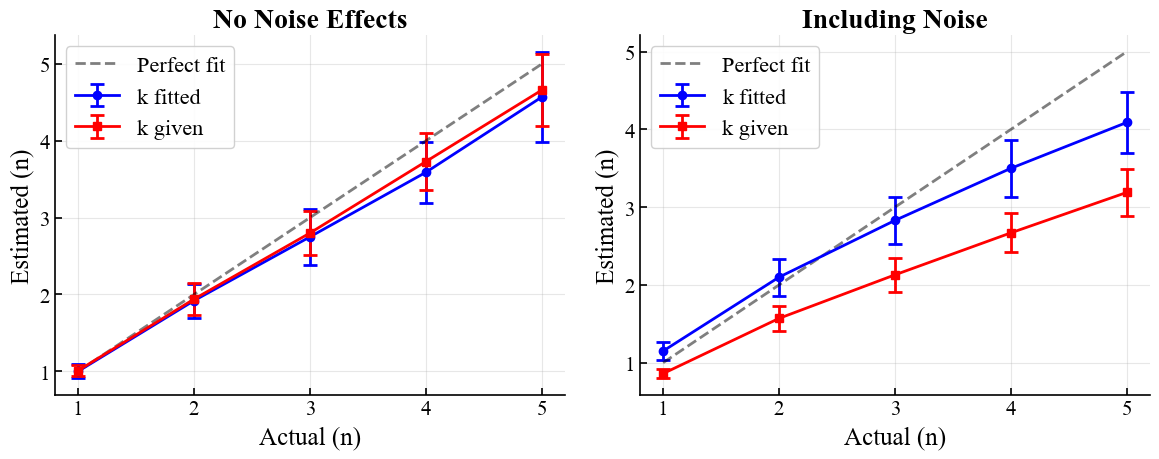

In [3]:
# results (from file: assess_fitting_quality_emitters):

# results with method='with_k', 100kw/cm2, 0.1ms measurement time, no noise effects
# this fits k as well
#==================================================
#SUMMARY STATISTICS
#==================================================
#Actual: 1 | Estimated: 1.05 ± 0.09 | Error: 5.2%
#Actual: 2 | Estimated: 1.88 ± 0.20 | Error: 5.8%
#Actual: 3 | Estimated: 2.73 ± 0.25 | Error: 9.1%
#Actual: 4 | Estimated: 3.56 ± 0.32 | Error: 11.0%
#Actual: 5 | Estimated: 4.37 ± 0.54 | Error: 12.5%

# INCLUDING NOISE
# Standard spad23 noise config
#==================================================
#Actual: 1 | Estimated: 1.27 ± 0.17 | Error: 27.3%
#Actual: 2 | Estimated: 2.31 ± 0.49 | Error: 15.3%
#Actual: 3 | Estimated: 3.50 ± 0.35 | Error: 16.7%
#Actual: 4 | Estimated: 4.29 ± 0.39 | Error: 7.2%
#Actual: 5 | Estimated: 4.78 ± 0.61 | Error: 4.4%

# results with method='without_k', 100kw/cm2, 0.1ms measurement time, no noise effects
# this assumes k=min(k_ex, k_em) (the effective rate)
#==================================================
#SUMMARY STATISTICS
#==================================================
#Actual: 1 | Estimated: 1.17 ± 0.07 | Error: 16.9%
#Actual: 2 | Estimated: 2.08 ± 0.23 | Error: 3.8%
#Actual: 3 | Estimated: 3.04 ± 0.28 | Error: 1.5%
#Actual: 4 | Estimated: 3.94 ± 0.40 | Error: 1.6%
#Actual: 5 | Estimated: 4.92 ± 0.52 | Error: 1.6%

# INCLUDING NOISE
# Standard spad23 noise config
#==================================================
#Actual: 1 | Estimated: 1.07 ± 0.09 | Error: 7.1%
#Actual: 2 | Estimated: 1.86 ± 0.33 | Error: 7.0%
#Actual: 3 | Estimated: 2.78 ± 0.34 | Error: 7.4%
#Actual: 4 | Estimated: 3.44 ± 0.34 | Error: 14.0%
#Actual: 5 | Estimated: 3.85 ± 0.65 | Error: 23.1%


# Data extraction
actual_values = [1, 2, 3, 4, 5]

# No noise data
# with_k_no_noise = [1.05, 1.88, 2.73, 3.56, 4.37]
# with_k_no_noise_err = [0.09, 0.20, 0.25, 0.32, 0.54]

# without_k_no_noise = [1.17, 2.08, 3.04, 3.94, 4.92]
# without_k_no_noise_err = [0.07, 0.23, 0.28, 0.40, 0.52]

# # With noise data
# with_k_noise = [1.27, 2.31, 3.50, 4.29, 4.78]
# with_k_noise_err = [0.17, 0.49, 0.35, 0.39, 0.61]

# without_k_noise = [1.07, 1.86, 2.78, 3.44, 3.85]
# without_k_noise_err = [0.09, 0.33, 0.34, 0.34, 0.65]

with_k_no_noise = [1.00, 1.92, 2.75, 3.59, 4.57]
with_k_no_noise_err = [0.09, 0.22, 0.36, 0.40, 0.59]

without_k_no_noise = [1.01, 1.94, 2.80, 3.73, 4.66]
without_k_no_noise_err = [0.07, 0.21, 0.29, 0.37, 0.47]

# With noise data
with_k_noise = [1.15, 2.10, 2.83, 3.50, 4.09]
with_k_noise_err = [0.11, 0.24, 0.30, 0.37, 0.39]

without_k_noise = [0.86, 1.57, 2.13, 2.67, 3.19]
without_k_noise_err = [0.06, 0.16, 0.22, 0.25, 0.30]

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot: No noise
ax1.errorbar(actual_values, with_k_no_noise, yerr=with_k_no_noise_err, 
             fmt='o-', label='k fitted', capsize=5, capthick=2, color='b')
ax1.errorbar(actual_values, without_k_no_noise, yerr=without_k_no_noise_err, 
             fmt='s-', label='k given', capsize=5, capthick=2, color = 'r')
ax1.plot(actual_values, actual_values, 'k--', alpha=0.5, label='Perfect fit')
ax1.set_xlabel('Actual (n)', fontsize=18)
ax1.set_ylabel('Estimated (n)', fontsize=18)
ax1.set_title('No Noise Effects', fontsize=20)
ax1.legend(fontsize=16)
ax1.grid(True, alpha=0.3)

# Right subplot: With noise
ax2.errorbar(actual_values, with_k_noise, yerr=with_k_noise_err, 
             fmt='o-', label=r'$k$ fitted', capsize=5, capthick=2, color='b')
ax2.errorbar(actual_values, without_k_noise, yerr=without_k_noise_err, 
             fmt='s-', label='k given', capsize=5, capthick=2, color='r')
ax2.plot(actual_values, actual_values, 'k--', alpha=0.5, label='Perfect fit')
ax2.set_xlabel('Actual (n)', fontsize=18)
ax2.set_ylabel('Estimated (n)', fontsize=18)
ax2.set_title('Including Noise', fontsize=20)
ax2.legend(fontsize=16)
ax2.grid(True, alpha=0.3)

# Adjust layout and show
plt.tight_layout()
plt.show()

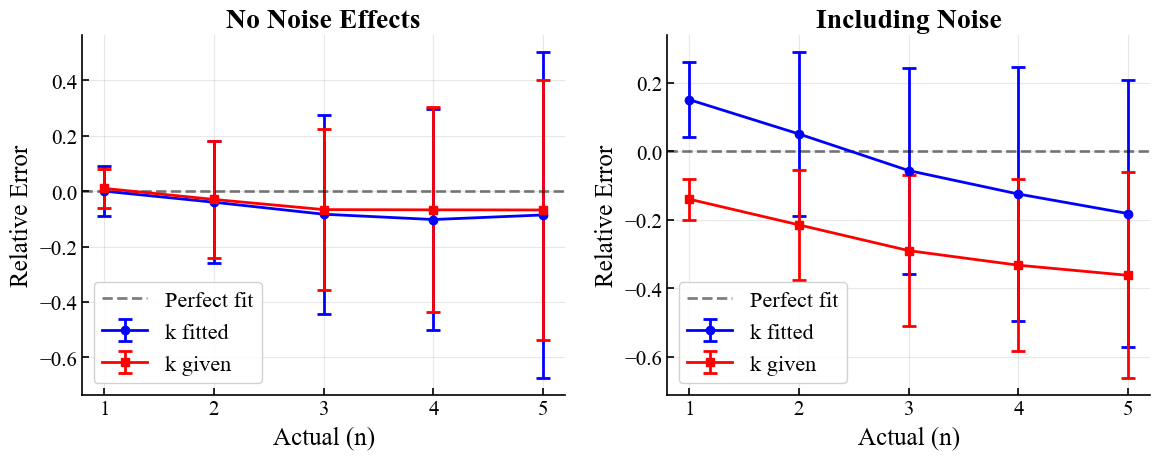

In [4]:
# Relative error function
def relative_error(estimated, actual):
    return [(e - a)/a for e, a in zip(estimated, actual)]

# Relative errors
with_k_no_noise_rel = relative_error(with_k_no_noise, actual_values)
without_k_no_noise_rel = relative_error(without_k_no_noise, actual_values)

with_k_noise_rel = relative_error(with_k_noise, actual_values)
without_k_noise_rel = relative_error(without_k_noise, actual_values)

# Relative error plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# No noise
ax1.errorbar(actual_values, with_k_no_noise_rel, yerr=with_k_no_noise_err, 
             fmt='o-', label='k fitted', capsize=5, capthick=2, color='b')
ax1.errorbar(actual_values, without_k_no_noise_rel, yerr=without_k_no_noise_err, 
             fmt='s-', label='k given', capsize=5, capthick=2, color='r')
ax1.axhline(0, color='k', linestyle='--', alpha=0.5, label='Perfect fit')
ax1.set_xlabel('Actual (n)', fontsize=18)
ax1.set_ylabel('Relative Error', fontsize=18)
ax1.set_title('No Noise Effects', fontsize=20)
ax1.legend(fontsize=16)
ax1.grid(True, alpha=0.3)

# With noise
ax2.errorbar(actual_values, with_k_noise_rel, yerr=with_k_noise_err, 
             fmt='o-', label='k fitted', capsize=5, capthick=2, color='b')
ax2.errorbar(actual_values, without_k_noise_rel, yerr=without_k_noise_err, 
             fmt='s-', label='k given', capsize=5, capthick=2, color='r')
ax2.axhline(0, color='k', linestyle='--', alpha=0.5, label='Perfect fit')
ax2.set_xlabel('Actual (n)', fontsize=18)
ax2.set_ylabel('Relative Error', fontsize=18)
ax2.set_title('Including Noise', fontsize=20)
ax2.legend(fontsize=16)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Without noise performance overview

Processing 10 evaluations with 3 run patterns...

Processing evaluation 1/10: project/data/evaluation_20250811_215207/
  Processing pattern: run_000*.h5


Processing repetitions:   0%|          | 0/3 [00:00<?, ?it/s]

PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085
PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085


Processing repetitions: 100%|██████████| 3/3 [00:00<00:00, 17.35it/s]

PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085


Processing repetitions: 100%|██████████| 3/3 [00:00<00:00, 11.47it/s]


ESTPOS
[[-0.03891131 -0.37178081]
 [-0.03891131 -0.37178081]
 [-0.03891131 -0.37178081]]
GTPOS
[[-0.37101171 -0.03884382]]
STD: [3.36953248e-11 9.92136089e-12]


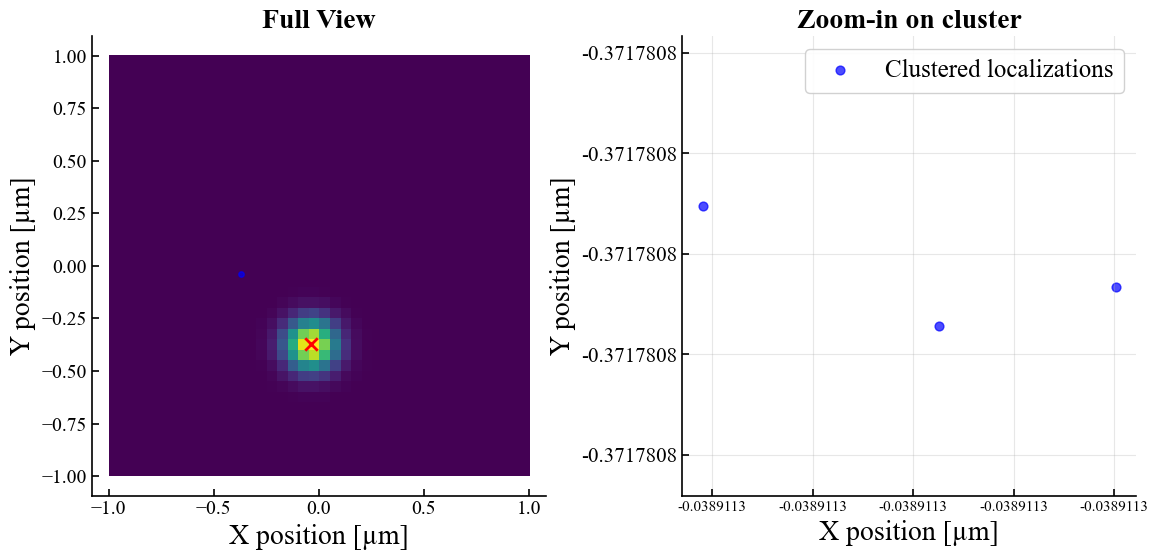

C:\Users/rensv/Onedrive - Delft University of Technology/MEP-RensPad/SPAD SMLM/spad-smlm\project\simulations\compute_localization_bias_precision.py:234: RuntimeWarning: Mean of empty slice
  mean_rel_coord = np.nanmean(rel_coords, axis=0)
c:\Users\rensv\OneDrive - Delft University of Technology\MEP-RensPad\SPAD SMLM\spad-smlm\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  Spread plot saved: test_spread.png
Run 0: TP=0, FP=1, FN=1
Run 1: TP=0, FP=1, FN=1
Run 2: TP=0, FP=1, FN=1
Jaccard over all repetitions: [np.float64(0.0), np.float64(0.0), np.float64(0.0)]
  Processing pattern: run_001*.h5


Processing repetitions:  67%|██████▋   | 2/3 [00:00<00:00, 16.60it/s]

PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085
PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085


Processing repetitions: 100%|██████████| 3/3 [00:00<00:00, 10.08it/s]


PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085
ESTPOS
[[-0.06406564  0.09740562]
 [-0.06406564  0.09740562]
 [-0.06406564  0.09740562]]
GTPOS
[[ 0.0978058  -0.06406621]]
STD: [6.62009545e-11 6.50339380e-11]


In [ ]:

#directories for evaluations without noise (TO BE RUN)
evaluation_directories = [
    "project/data/evaluation_20250811_215207/",
    "project/data/evaluation_20250811_215416/",
    "project/data/evaluation_20250811_215840/",
    "project/data/evaluation_20250811_220400/",
    "project/data/evaluation_20250811_221134/",
    "project/data/evaluation_20250811_222149/",
    "project/data/evaluation_20250811_223310/",
    "project/data/evaluation_20250811_224624/",
    "project/data/evaluation_20250811_230053/",
    "project/data/evaluation_20250811_231712/",
]

    # Run comparison with multiple run patterns
comparison_results = compare_evaluations_multi_run(
    evaluation_directories, 
    run_patterns=['run_000*.h5', 'run_001*.h5', 'run_002*.h5'],
    n_repetitions=3,
    save_path_prefix="multi_run_evaluation_comparison",
    max_distance=0.020 #micrometer., or 20 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP
)

# Access results
print(f"\nMean biases: {comparison_results['mean_biases']}")
print(f"Bias errors: {comparison_results['bias_errors']}")
print(f"Mean precisions: {comparison_results['mean_precisions']}")
print(f"Precision errors: {comparison_results['precision_errors']}")

# Store comparison results to a .json file
import json
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

def nan_to_none(arr):
    return [None if (isinstance(x, float) and np.isnan(x)) else x for x in arr]

comparison_results['all_biases'] = [nan_to_none(b) for b in comparison_results['all_biases']]
comparison_results['all_precisions'] = [nan_to_none(p) for p in comparison_results['all_precisions']]
comparison_results['all_biases_std'] = [nan_to_none(b) for b in comparison_results['all_biases_std']]
comparison_results['all_precisions_std'] = [nan_to_none(p) for p in comparison_results['all_precisions_std']]
comparison_results['all_jaccards'] = [nan_to_none(j) for j in comparison_results['all_jaccards']]
comparison_results['all_jaccard_std'] = [nan_to_none(j) for j in comparison_results['all_jaccard_std']]

comparison_results['all_biases_dir'] = [nan_to_none(b) for b in comparison_results['all_biases_dir']]




with open(f'comparison_results_{timestamp}.json', 'w') as f:
    json.dump(comparison_results, f, indent=4)

# Example usage of the compare_evaluations function

## Including Noise performance overview

Processing 1 evaluations with 1 run patterns...

Processing evaluation 1/1: project/data/evaluation_20250804_131603/
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
  Summary for evaluation_20250804_131603:
    Mean of mean distances: 0.010313 ± 0.000000
    Mean of within-run stds: 0.007310 ± 0.000000
    Mean Jaccard index: 1.000000 ± 0.000000


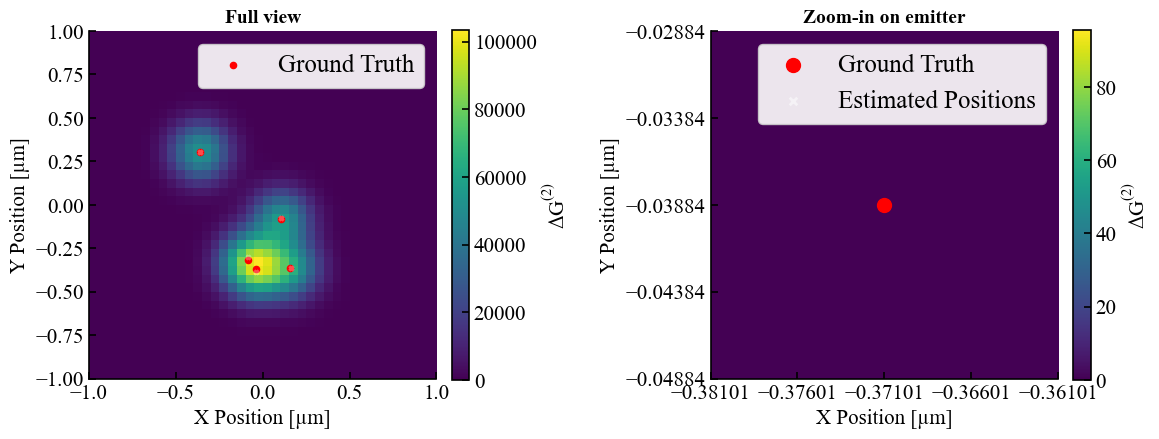

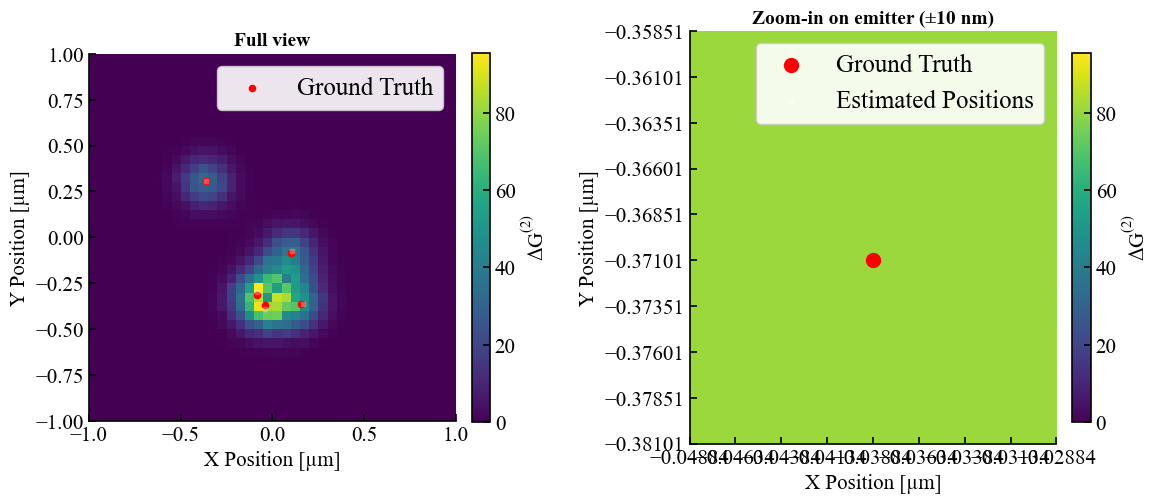


Results saved to: multi_run_evaluation_comparison_localization_metrics_20250918_142308.json

LOCALIZATION PERFORMANCE SUMMARY
Evaluation                     Mean±Std [µm]        Within-Run±Std [µm]  Jaccard±Std    
-------------------------------------------------------------------------------------
evaluation_20250804_131603     10.3±0.0             7.3±0.0              1.000±0.000    


In [2]:

################# This bit produces a localization precision plot (of 100 repeated localizations of same ground truth) ###################

evaluation_directories = [
#"project/data/evaluation_20250804_125707/",
#"project/data/evaluation_20250804_125907/",
#"project/data/evaluation_20250804_130258/",
# "project/data/evaluation_20250804_130836/",
 "project/data/evaluation_20250804_131603/",
#  "project/data/evaluation_20250804_132520/",
#  "project/data/evaluation_20250804_133624/",
#  "project/data/evaluation_20250804_134928/",
# "project/data/evaluation_20250804_140424/",
#  "project/data/evaluation_20250804_142103/",
]

# evaluation_directories = [
# "project/data/evaluation_20250904_164444/",
# ]

######## Old method ######### [works by repetitions: localizes many times the same ground truth image]
# comparison_results = compare_evaluations_multi_run(
#     evaluation_directories, 
#     run_patterns=['run_002*.h5'],#,#'run_001*.h5', 'run_002*.h5'],
#     n_repetitions=5,
#     save_path_prefix="multi_run_evaluation_comparison",
#     max_distance=0.020 #micrometer., or 20 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP)
# )

#####################################################

######### New method ###########

#evaluation_directories = [
#     "project/data/evaluation_20250829_185738/",
#     "project/data/evaluation_20250829_190115/",
#     "project/data/evaluation_20250829_190751/",
#     "project/data/evaluation_20250829_191606/",
#     "project/data/evaluation_20250829_192713/",
#     "project/data/evaluation_20250829_194046/",
#     "project/data/evaluation_20250829_195658/",
#     "project/data/evaluation_20250829_201600/",
#     "project/data/evaluation_20250829_203750/",
#     "project/data/evaluation_20250829_210235/"
# ]

#fancy subtraction method data not to be used i think
# evaluation_directories = [
#     "project/data/evaluation_20250909_204833/",
#     "project/data/evaluation_20250909_205946/",
#     "project/data/evaluation_20250909_212125/",
#     "project/data/evaluation_20250909_215451/",
#     "project/data/evaluation_20250909_224412/",
#     "project/data/evaluation_20250909_234121/",
#     "project/data/evaluation_20250910_003708/",
#     "project/data/evaluation_20250910_012555/",
#     "project/data/evaluation_20250910_021924/",
#     "project/data/evaluation_20250910_025824/"
# ]

comparison_results = compare_evaluations_multi_run_revised(
    evaluation_directories,
    run_patterns=[f"run_{i:03d}*.h5" for i in range(1)],
    plot_localization=True,
    save_path_prefix="multi_run_evaluation_comparison",
    max_distance=0.020 #micrometer., or 10 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP)
)


####### Deprecated ########


# Access results
#print(f"\nMean biases: {comparison_results['mean_biases']}")
#print(f"Bias errors: {comparison_results['bias_errors']}")
#print(f"Mean precisions: {comparison_results['mean_precisions']}")
#print(f"Precision errors: {comparison_results['precision_errors']}")
#print(f"All biases: {comparison_results['all_biases']}")
#print(f"Biases errors: {comparison_results['all_biases_std']}")

# Store comparison results to a .json file
# import json
# import datetime
# timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# def nan_to_none(arr):
#     return [None if (isinstance(x, float) and np.isnan(x)) else x for x in arr]


# comparison_results['all_biases'] = [nan_to_none(b) for b in comparison_results['all_biases']]
# comparison_results['all_precisions'] = [nan_to_none(p) for p in comparison_results['all_precisions']]
# comparison_results['all_biases_std'] = [nan_to_none(b) for b in comparison_results['all_biases_std']]
# comparison_results['all_precisions_std'] = [nan_to_none(p) for p in comparison_results['all_precisions_std']]
# comparison_results['all_jaccards'] = [nan_to_none(j) for j in comparison_results['all_jaccards']]
# comparison_results['all_jaccard_std'] = [nan_to_none(j) for j in comparison_results['all_jaccard_std']]

# comparison_results['all_biases_dir'] = [nan_to_none(b) for b in comparison_results['all_biases_dir']]

# with open(f'comparison_results_{timestamp}.json', 'w') as f:
#     json.dump(comparison_results, f, indent=4)

# Example usage of the compare_evaluations function


#### New method 100 sims per eval #####

# comparison_results = compare_evaluations_multi_run_revised(
#     evaluation_directories,
#     run_patterns=[f"run_{i:03d}*.h5" for i in range(25)],
#     save_path_prefix="multi_run_evaluation_comparison",
#     max_distance=0.020 #micrometer., or 10 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP)
# )

## Different deadtimes

In [ ]:
# Dead time varying runs

# evaluation_directories = [
# "project/data/evaluation_20250805_134844/", #0
# "project/data/evaluation_20250805_220419", #5
# "project/data/evaluation_20250807_000657", #10
# "project/data/evaluation_20250807_001849", #15
# "project/data/evaluation_20250807_003137", #20
# "project/data/evaluation_20250807_092818", #25
# "project/data/evaluation_20250807_094021", #30
# "project/data/evaluation_20250807_095502", #35
# "project/data/evaluation_20250807_101544", #40
# "project/data/evaluation_20250807_102916", #45
# "project/data/evaluation_20250807_105359", #50
# ]

#     # Run comparison with multiple run patterns
# comparison_results = compare_evaluations_multi_run(
#     evaluation_directories, 
#     run_patterns=['run_000*.h5', 'run_001*.h5', 'run_002*.h5'],
#     n_repetitions=25,
#     save_path_prefix="multi_run_evaluation_comparison",
#     x_positions_given=[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50], # Dead time in ms
#     max_distance=0.020 #micrometer., or 20 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP
# )

# # Access results
# print(f"\nMean biases: {comparison_results['mean_biases']}")
# print(f"Bias errors: {comparison_results['bias_errors']}")
# print(f"Mean precisions: {comparison_results['mean_precisions']}")
# print(f"Precision errors: {comparison_results['precision_errors']}")

# # Store comparison results to a .json file
# import json
# import datetime
# timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# def nan_to_none(arr):
#     return [None if (isinstance(x, float) and np.isnan(x)) else x for x in arr]


# comparison_results['all_biases'] = [nan_to_none(b) for b in comparison_results['all_biases']]
# comparison_results['all_precisions'] = [nan_to_none(p) for p in comparison_results['all_precisions']]
# comparison_results['all_biases_std'] = [nan_to_none(b) for b in comparison_results['all_biases_std']]
# comparison_results['all_precisions_std'] = [nan_to_none(p) for p in comparison_results['all_precisions_std']]
# comparison_results['all_jaccards'] = [nan_to_none(j) for j in comparison_results['all_jaccards']]
# comparison_results['all_jaccard_std'] = [nan_to_none(j) for j in comparison_results['all_jaccard_std']]

# comparison_results['all_biases_dir'] = [nan_to_none(b) for b in comparison_results['all_biases_dir']]

# with open(f'comparison_results_{timestamp}.json', 'w') as f:
#     json.dump(comparison_results, f, indent=4)

# # Example usage of the compare_evaluations function


####### new ##########

# evaluation_directories = [
#     "project/data/evaluation_20250828_155028/",
#     "project/data/evaluation_20250828_160837/",
#     "project/data/evaluation_20250828_165742/",
# ]

evaluation_directories = [
    "project/data/evaluation_20250829_180741/",
    "project/data/evaluation_20250829_182210/",
    "project/data/evaluation_20250829_183316/",
    "project/data/evaluation_20250829_184518/",

]

# new 100x simulations
evaluation_directories = [
    "project/data/evaluation_20250906_003958/",
    "project/data/evaluation_20250906_005611/",
    "project/data/evaluation_20250906_075921/",
    "project/data/evaluation_20250906_081344/",
]


comparison_results = compare_evaluations_multi_run_revised(
    evaluation_directories,
    run_patterns=[f"run_{i:03d}*.h5" for i in range(100)],
    save_path_prefix="multi_run_evaluation_comparison_deadtimes",
    max_distance=0.020 #micrometer., or 10 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP)
)


Processing 4 evaluations with 100 run patterns...

Processing evaluation 1/4: project/data/evaluation_20250906_003958/
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Ampli

## Large FOV

Processing 1 evaluations with 1 run patterns...

Processing evaluation 1/1: project/data/evaluation_20250830_064722/
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971


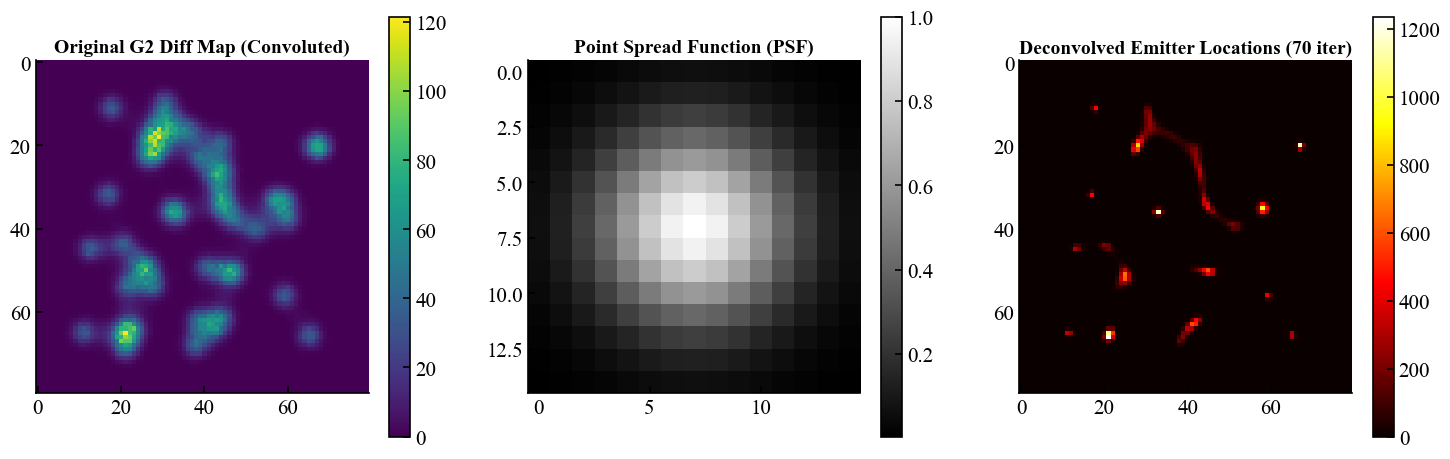

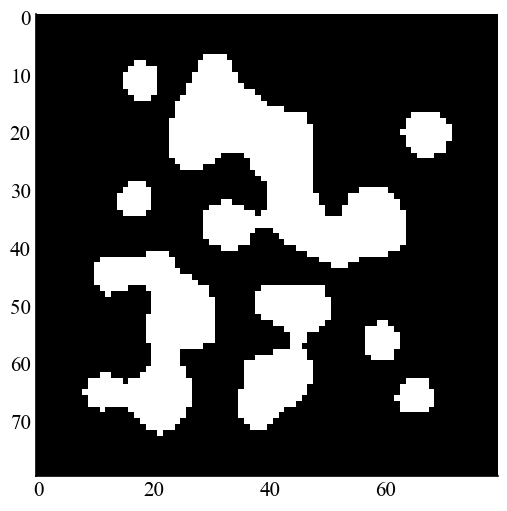

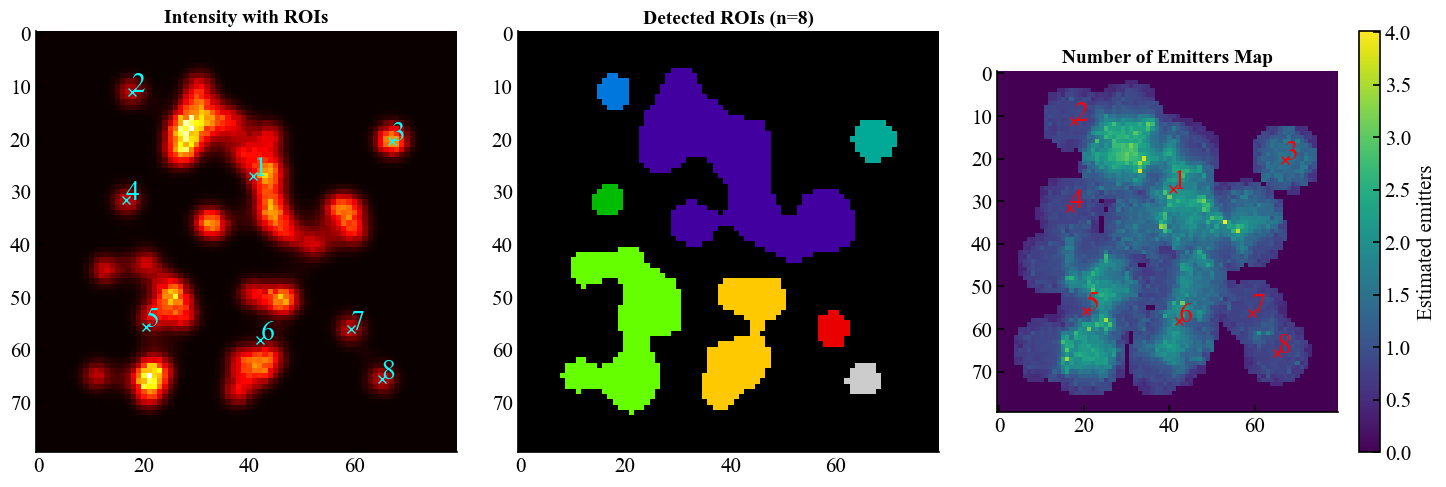


ROI Statistics:
--------------------------------------------------------------------------------
Label  |  Area  |   X    |   Y    |  Mean Int  | Mean Emitters  | Median Emitters |  Max Emitters  | Total Emitters |   Gd Sum  
--------------------------------------------------------------------------------
1.000000 | 668.000000 |  40.8  |  27.0  |  54834.16  |      1.81      |      1.75      |      4.01      |    1207.76     |  23068.88 
2.000000 | 33.000000 |  17.7  |  11.1  |  38473.03  |      0.84      |      0.84      |      0.92      |     27.73      |   552.11  
3.000000 | 53.000000 |  67.2  |  20.3  |  58289.19  |      1.40      |      1.40      |      1.61      |     74.21      |  1625.74  
4.000000 | 30.000000 |  16.6  |  31.6  |  40121.70  |      0.84      |      0.84      |      0.89      |     25.08      |   545.90  
5.000000 | 365.000000 |  20.4  |  55.7  |  49951.87  |      1.60      |      1.66      |      3.42      |     584.55     |  10464.92 
6.000000 | 227.000000 |  

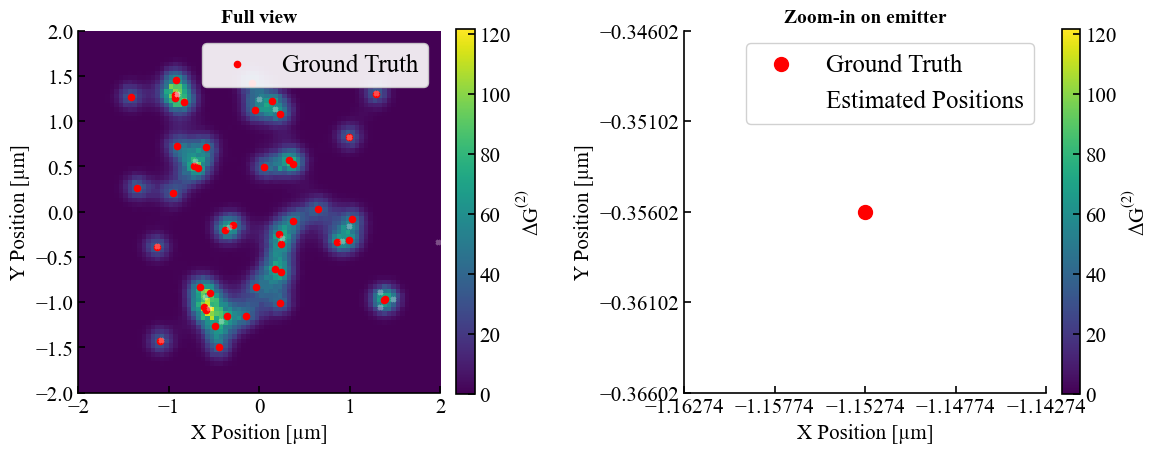

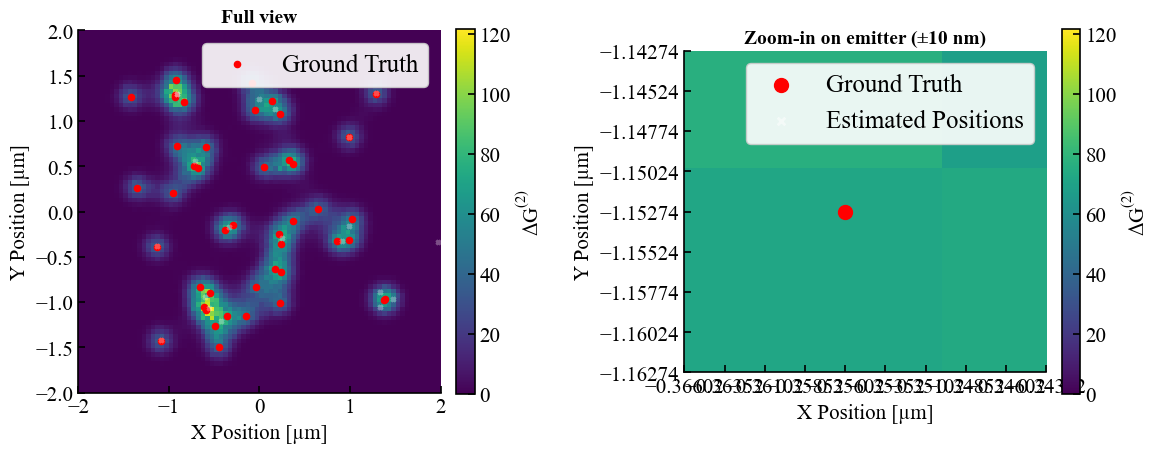


Results saved to: testX_localization_metrics_20250917_213148.json

LOCALIZATION PERFORMANCE SUMMARY
Evaluation                     Mean±Std [µm]        Within-Run±Std [µm]  Jaccard±Std    
-------------------------------------------------------------------------------------
evaluation_20250830_064722     4.2±0.0              0.6±0.0              0.066±0.000    


In [5]:

evaluation_directories = [
    "project/data/evaluation_20250828_093700/",
    "project/data/evaluation_20250828_095343/",
    "project/data/evaluation_20250828_103102/",
    "project/data/evaluation_20250828_114726/",
    "project/data/evaluation_20250828_133403/",
]

evaluation_directories = [
    #"project/data/evaluation_20250830_002319/",
    #"project/data/evaluation_20250830_010213/",
    #"project/data/evaluation_20250830_021924/",
    #"project/data/evaluation_20250830_041759/",
    "project/data/evaluation_20250830_064722/",
]

# comparison_results = compare_evaluations_multi_run_revised(
#     evaluation_directories,
#     run_patterns=[f"run_{i:03d}*.h5" for i in range(100)],
#     save_path_prefix="multi_run_evaluation_comparison_largeFOV",
#     max_distance=0.020 #micrometer., or 10 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP)
# )

comparison_results = compare_evaluations_multi_run_revised(
    evaluation_directories,
    run_patterns=[f"run_042*.h5" for i in range(1)],
    plot_localization=True,
    plot=True,
    save_path_prefix="testX",
    max_distance=0.020 #micrometer., or 10 nm. Should be close to expected resolution. This is the maximum distance to consider a localization as true positive (TP) or false positive (FP)
)


## Visualising no-noise localizations

PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085
PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085
PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085
PSF G used: Amplitude: 73.18181868619972, Sigma: 0.085


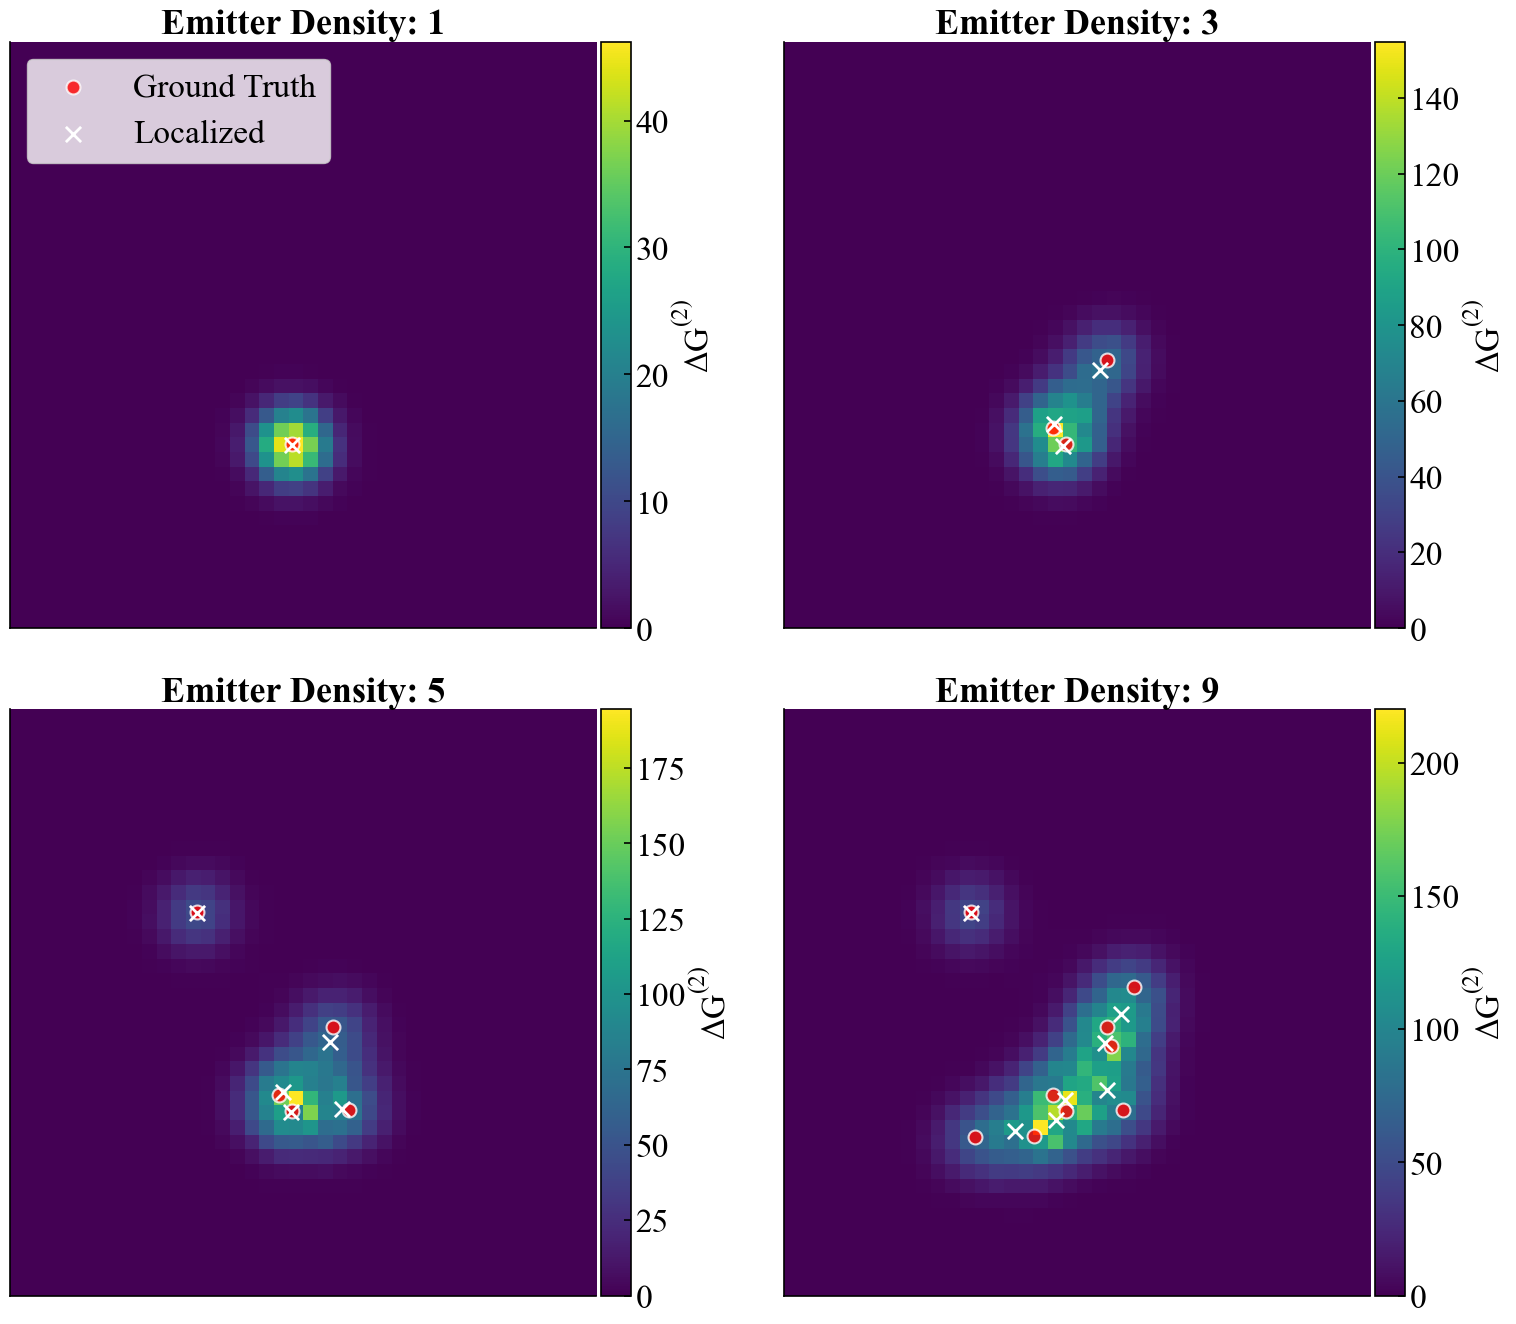

In [ ]:
## Visualising no noise images: 
# emitter densities 1,3,5,9

evaluation_directories = [
    "project/data/evaluation_20250811_215207/",
    "project/data/evaluation_20250811_215416/",
    "project/data/evaluation_20250811_215840/",
    "project/data/evaluation_20250811_220400/",
    "project/data/evaluation_20250811_221134/",
    "project/data/evaluation_20250811_222149/",
    "project/data/evaluation_20250811_223310/",
    "project/data/evaluation_20250811_224624/",
    "project/data/evaluation_20250811_230053/",
    "project/data/evaluation_20250811_231712/",
]

# After running your comparison
results = plot_evaluation_examples(
    evaluation_directories,
    save_path_prefix="nonoise_comparison_fig",
    map_type='G2_map'  # or 'nr_emitters_map' or 'photon_count_map'
)

## Visualising noise images

PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971


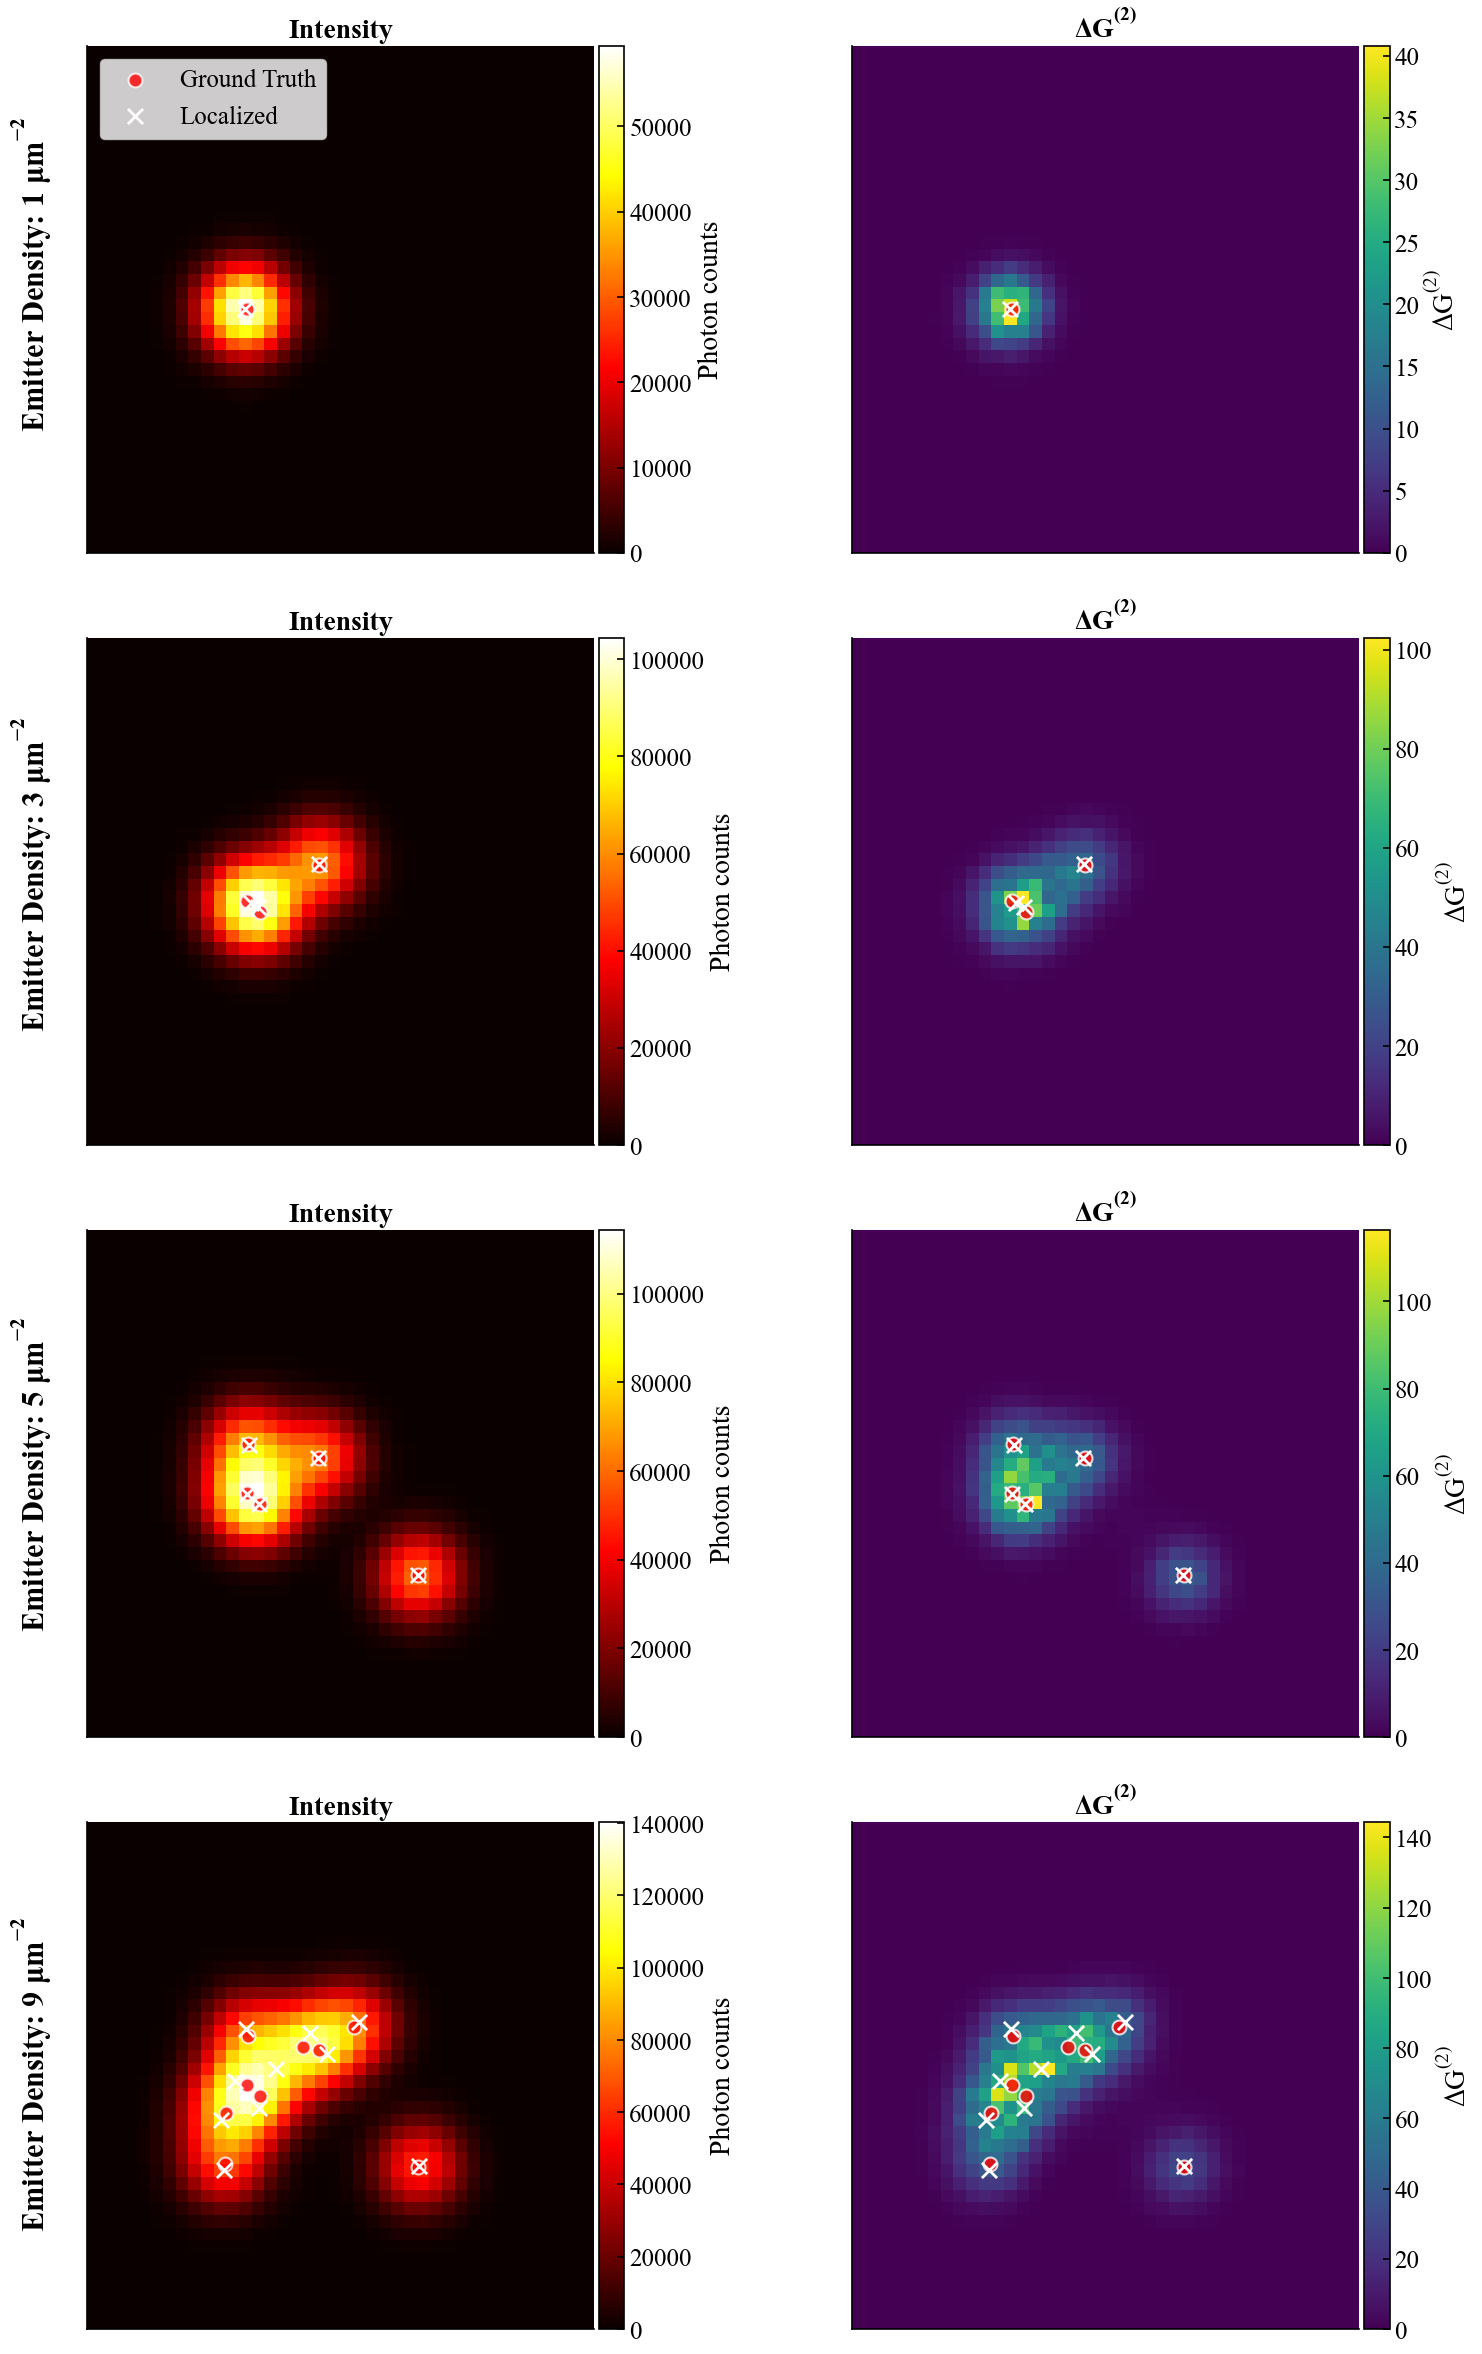

In [ ]:
## Visualising noise images: 
# emitter densities 1,3,5,9

evaluation_directories = [
"project/data/evaluation_20250804_125707/",
"project/data/evaluation_20250804_125907/",
"project/data/evaluation_20250804_130258/",
"project/data/evaluation_20250804_130836/",
"project/data/evaluation_20250804_131603/",
 "project/data/evaluation_20250804_132520/",
 "project/data/evaluation_20250804_133624/",
 "project/data/evaluation_20250804_134928/",
"project/data/evaluation_20250804_140424/",
 "project/data/evaluation_20250804_142103/",
]

evaluation_directories = [ # this is with an augmented estimated nr emitters and magnification at 170 as it should
 "project/data/evaluation_20250826_095019/",
"project/data/evaluation_20250826_095214/",
"project/data/evaluation_20250826_095736",
"project/data/evaluation_20250826_095736"
]

evaluation_directories = [
    "project/data/evaluation_20250829_185738/",
    "project/data/evaluation_20250829_190115/",
    "project/data/evaluation_20250829_190751/",
    "project/data/evaluation_20250829_191606/",
    "project/data/evaluation_20250829_192713/",
    "project/data/evaluation_20250829_194046/",
    "project/data/evaluation_20250829_195658/",
    "project/data/evaluation_20250829_201600/",
    "project/data/evaluation_20250829_203750/",
    "project/data/evaluation_20250829_210235/"
]

# After running your comparison
results = plot_evaluation_examples(
    evaluation_directories,
    save_path_prefix="withnoiseV3_comparison_fig",
    map_type='G2_map'  # or 'nr_emitters_map' or 'photon_count_map'
)

## Deadtime variations images

PSF G used: Amplitude: 70, Sigma: 0.07680107543440003
PSF G used: Amplitude: 40.097081868765876, Sigma: 0.08419757087305174
PSF G used: Amplitude: 40.85182956993539, Sigma: 0.08298514932046748
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971


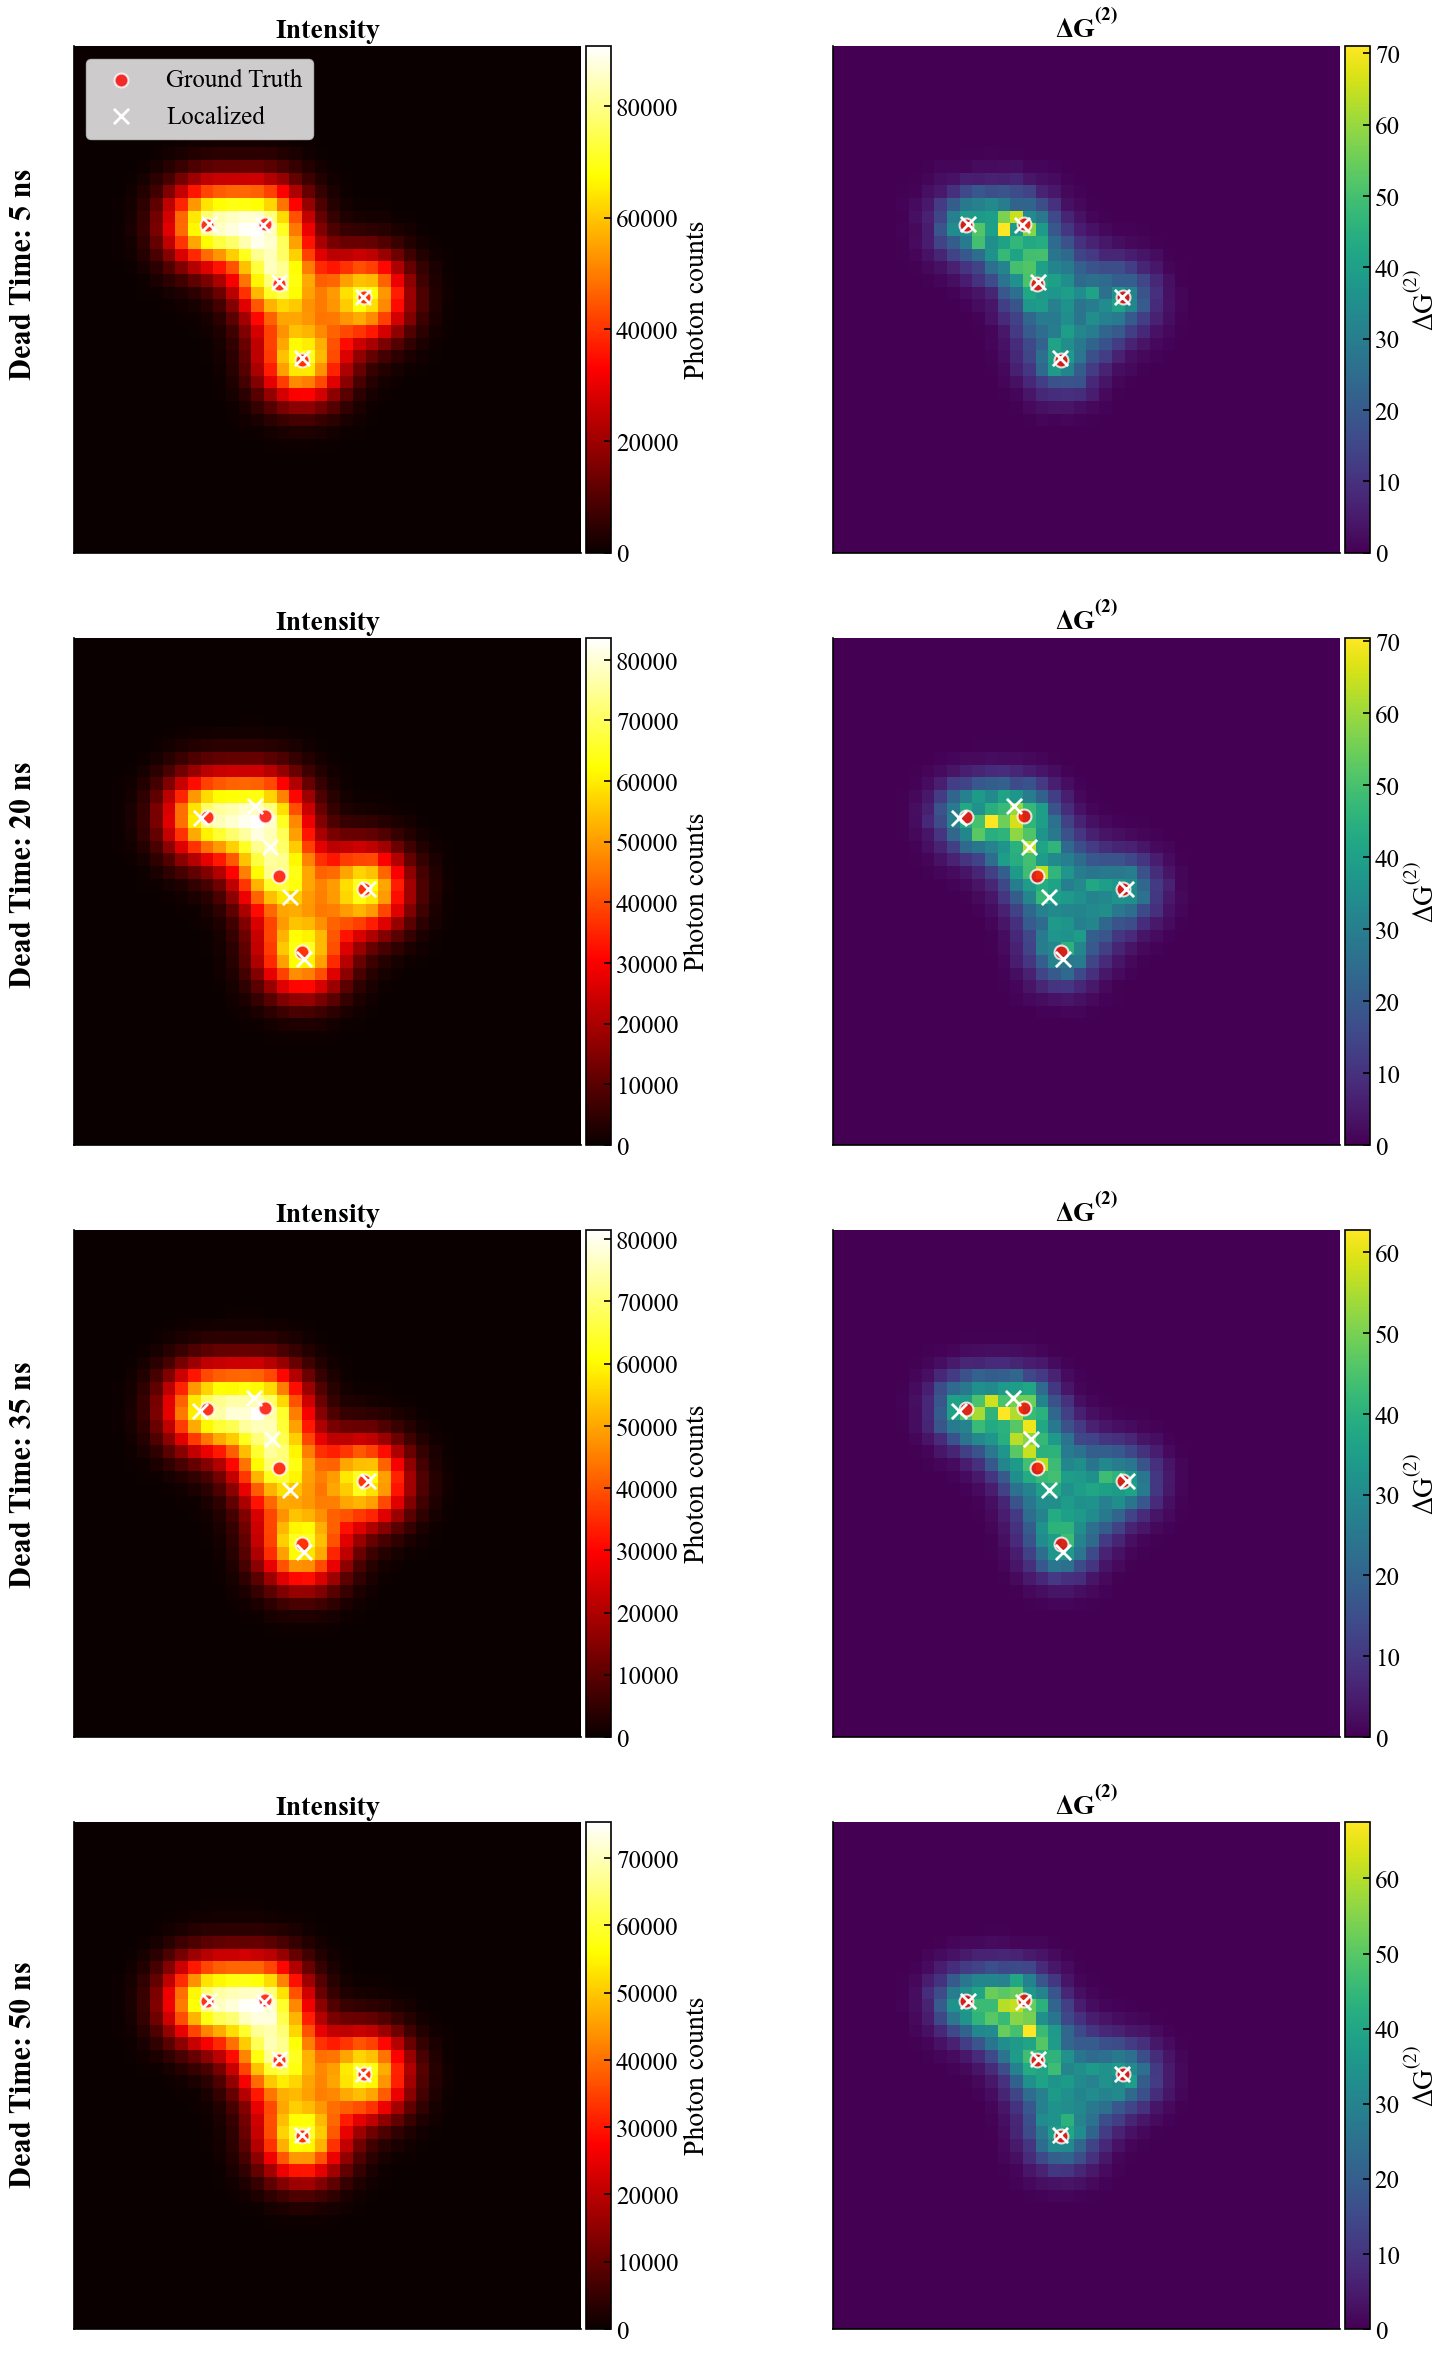

In [ ]:
# evaluation_directories = [
# #"project/data/evaluation_20250805_134844/", #0
# "project/data/evaluation_20250805_220419", #5
# "project/data/evaluation_20250807_000657", #10
# "project/data/evaluation_20250807_001849", #15
# "project/data/evaluation_20250807_003137", #20
# "project/data/evaluation_20250807_092818", #25
# "project/data/evaluation_20250807_094021", #30
# "project/data/evaluation_20250807_095502", #35
# "project/data/evaluation_20250807_101544", #40
# "project/data/evaluation_20250807_102916", #45
# "project/data/evaluation_20250807_105359", #50
# ]



# # After running your comparison
# results = plot_evaluation_examples(
#     evaluation_directories,
#     save_path_prefix="deadtime_comparison_fig",
#     map_type='nr_emitters_map'  # or 'nr_emitters_map' or 'photon_count_map'
# )

# evaluation_directories = [
#     "project/data/evaluation_20250824_220814",
#     "project/data/evaluation_20250824_222947",
#     "project/data/evaluation_20250825_094039",
#     "project/data/evaluation_20250825_094039",
# ]

# evaluation_directories = [
#     "project/data/evaluation_20250828_155028/",
#     "project/data/evaluation_20250828_160837/",
#     "project/data/evaluation_20250828_165742/",
#     "project/data/evaluation_20250828_165742/",
# ]

# Deadtime NEWEST
evaluation_directories = [
    "project/data/evaluation_20250829_180741/",
    "project/data/evaluation_20250829_182210/",
    "project/data/evaluation_20250829_183316/",
    "project/data/evaluation_20250829_184518/",

]

# After running your comparison
results = plot_example_localizations(
    evaluation_directories,
    save_path="deadtime_comparison_fig_examples.png",
    run_pattern='run_010*.h5',
    map_type='G2_map',  # or 'nr_emitters_map' or 'photon_count_map'
    #metadata_given=metadata,
    example_indices=[0,1,2,3],
    crop_image=False
)

## Large FOV images

PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971
PSF G used: Amplitude: 33.66364806749709, Sigma: 0.0824764542973971


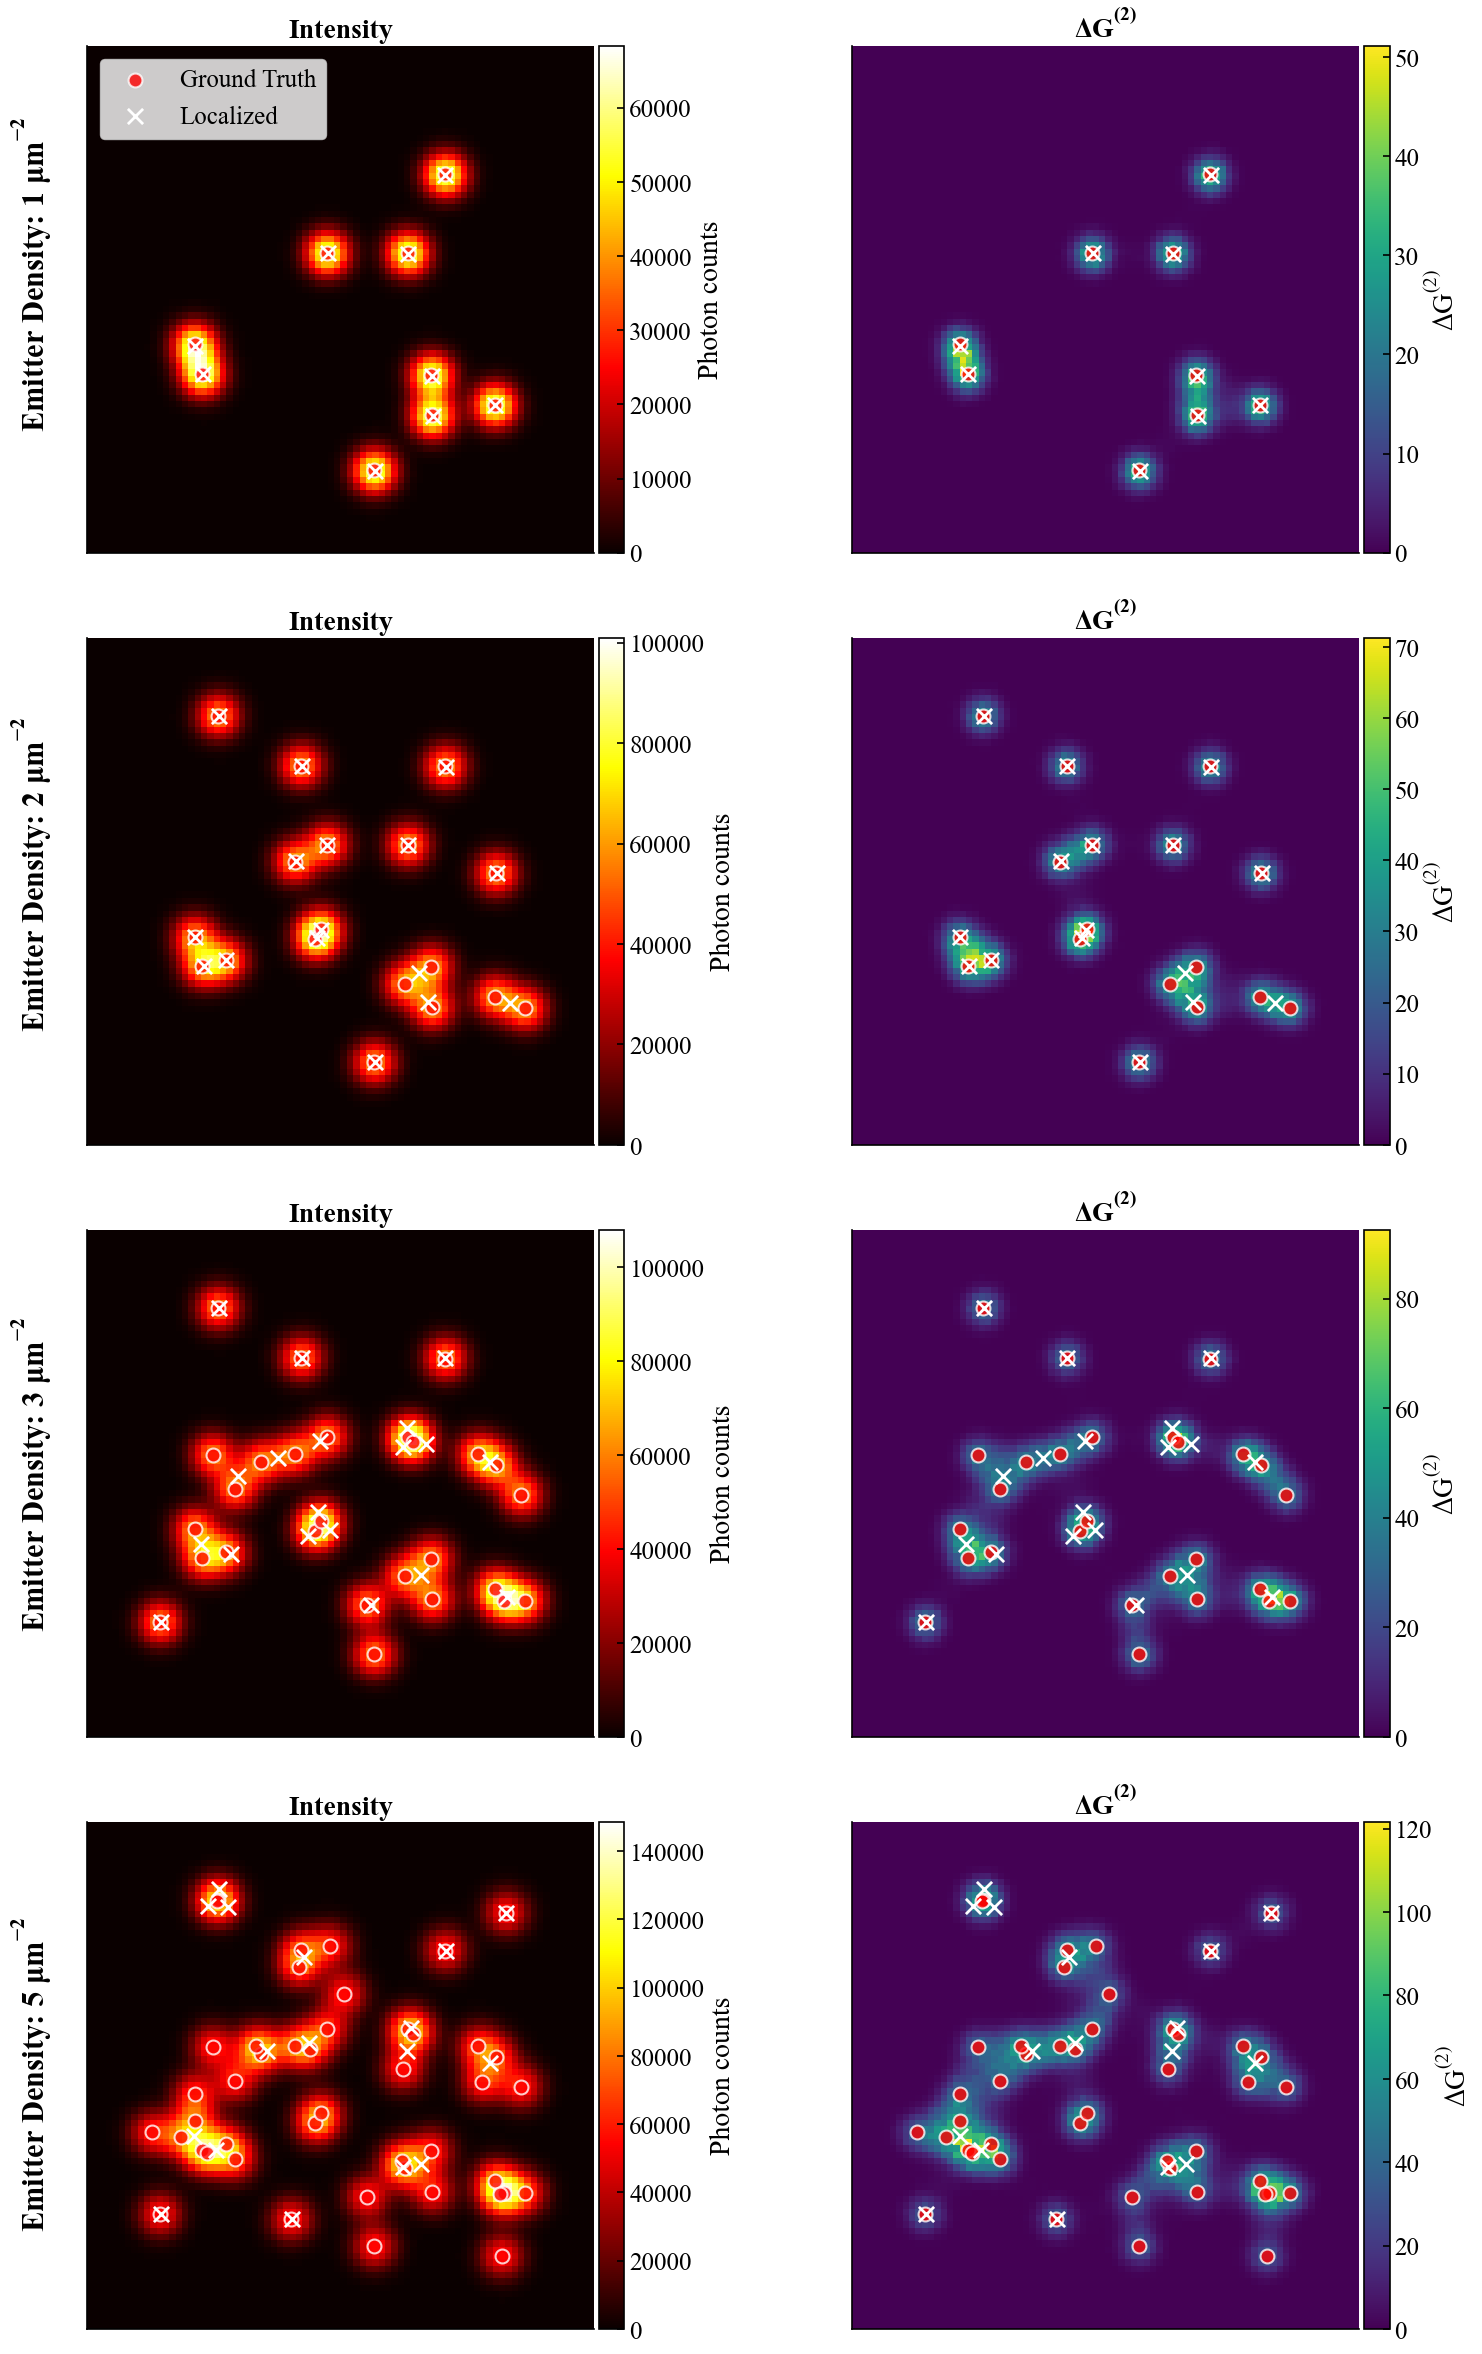

In [ ]:
## Visualising noise images: 
# emitter densities 1,2,3,5


evaluation_directories = [
    "project/data/evaluation_20250824_112718/",
    "project/data/evaluation_20250824_114531/",
    "project/data/evaluation_20250824_122802/",
    "project/data/evaluation_20250824_190617/",
    "project/data/evaluation_20250824_202052/",
]

evaluation_directories = [
    "project/data/evaluation_20250830_002319/",
    "project/data/evaluation_20250830_010213/",
    "project/data/evaluation_20250830_021924/",
    "project/data/evaluation_20250830_041759/",
    "project/data/evaluation_20250830_064722/",
]

# metadata = {
#     "afterpulsing": 0.0014,
#     "area_size": [4, 4],
#     "crosstalk": 0.001,
#     "dark_count_rate": 100,
#     "dead_time": 50,
#     "jitter": 0.12,
#     "detection_efficiency": 1.0,
#     "laser_power": 10000.0,
#     "magnification": 150,
#     "dwell_time": 2,
#     "positions": [80, 80],
#     "pixel_size": 0.050,
#     "enable_noise": True,
# }

results = plot_example_localizations(
    evaluation_directories,
    save_path="largefov_comparison_fig_examples.png",
    run_pattern='run_042*.h5',
    map_type='G2_map',  # or 'nr_emitters_map' or 'photon_count_map'
    #metadata_given=metadata,
    example_indices=[0,1,2,4],
    crop_image=False
)

## Emitter estimation ##

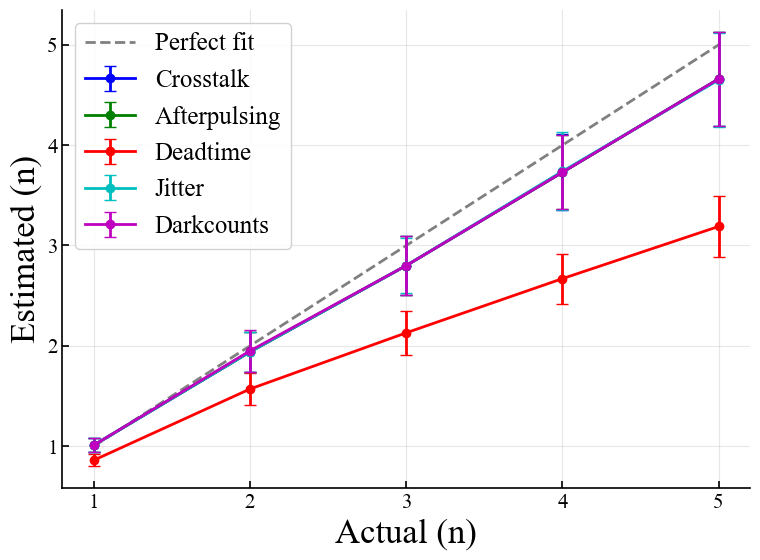

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Actual n values
n_actual = np.array([1, 2, 3, 4, 5])

# Estimated values and errors for each noise source
data = {
    "Crosstalk": {
        "est": np.array([1.01, 1.94, 2.80, 3.73, 4.66]),
        "err": np.array([0.07, 0.20, 0.29, 0.38, 0.47])
    },
    "Afterpulsing": {
        "est": np.array([1.01, 1.94, 2.80, 3.73, 4.66]),
        "err": np.array([0.07, 0.20, 0.29, 0.37, 0.47])
    },
    "Deadtime": {
        "est": np.array([0.86, 1.57, 2.13, 2.67, 3.19]),
        "err": np.array([0.06, 0.16, 0.22, 0.25, 0.30])
    },
    "Jitter": {
        "est": np.array([1.01, 1.94, 2.80, 3.74, 4.65]),
        "err": np.array([0.07, 0.20, 0.27, 0.39, 0.47])
    },
    "Darkcounts": {
        "est": np.array([1.01, 1.95, 2.80, 3.73, 4.66]),
        "err": np.array([0.07, 0.21, 0.29, 0.37, 0.47])
    }
}

# Plot
plt.figure(figsize=(8,6))

# Perfect fit line
plt.plot(n_actual, n_actual, '--', color='gray', label='Perfect fit')

# Plot each noise source with error bars
colors = ['b', 'g', 'r', 'c', 'm']
for i, (label, vals) in enumerate(data.items()):
    plt.errorbar(n_actual, vals["est"], yerr=vals["err"], marker='o', capsize=4, label=label, color=colors[i])

plt.xlabel("Actual (n)", fontsize=25)
plt.ylabel("Estimated (n)", fontsize=25)
#plt.xlim(0,6)
plt.xticks(n_actual)
#plt.title("Effect of Individual Noise Sources on Estimation (k given)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


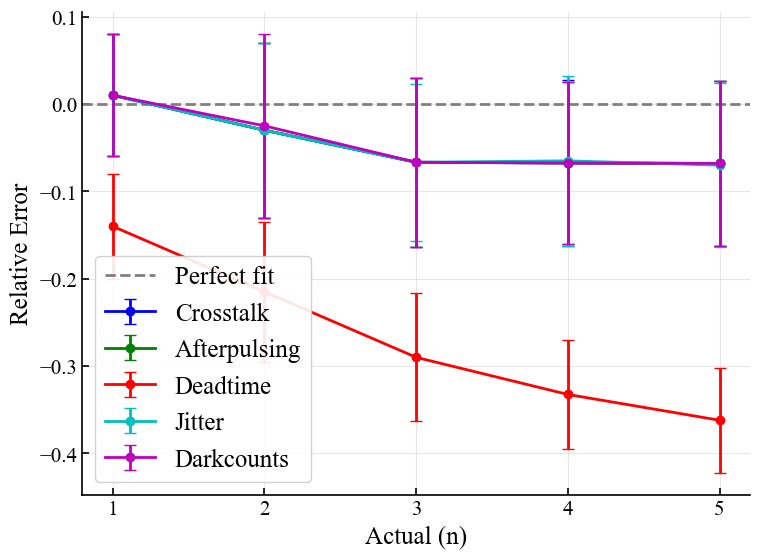

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Actual n values
n_actual = np.array([1, 2, 3, 4, 5])

# Estimated values and errors for each noise source
data = {
    "Crosstalk": {
        "est": np.array([1.01, 1.94, 2.80, 3.73, 4.66]),
        "err": np.array([0.07, 0.20, 0.29, 0.38, 0.47])
    },
    "Afterpulsing": {
        "est": np.array([1.01, 1.94, 2.80, 3.73, 4.66]),
        "err": np.array([0.07, 0.20, 0.29, 0.37, 0.47])
    },
    "Deadtime": {
        "est": np.array([0.86, 1.57, 2.13, 2.67, 3.19]),
        "err": np.array([0.06, 0.16, 0.22, 0.25, 0.30])
    },
    "Jitter": {
        "est": np.array([1.01, 1.94, 2.80, 3.74, 4.65]),
        "err": np.array([0.07, 0.20, 0.27, 0.39, 0.47])
    },
    "Darkcounts": {
        "est": np.array([1.01, 1.95, 2.80, 3.73, 4.66]),
        "err": np.array([0.07, 0.21, 0.29, 0.37, 0.47])
    }
}

# Function to compute relative error
def relative_error(estimated, actual):
    return (estimated - actual) / actual

# Plot relative errors
plt.figure(figsize=(8,6))

# Zero line (perfect fit)
plt.axhline(0, color='gray', linestyle='--', label='Perfect fit')

# Plot each noise source with relative error
colors = ['b', 'g', 'r', 'c', 'm']
for i, (label, vals) in enumerate(data.items()):
    rel_err = relative_error(vals["est"], n_actual)
    plt.errorbar(n_actual, rel_err, yerr=vals["err"]/n_actual,  # scale error bars to relative
                 marker='o', capsize=4, label=label, color=colors[i])

plt.xlabel("Actual (n)", fontsize=18)
plt.ylabel("Relative Error", fontsize=18)
plt.xticks(n_actual)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


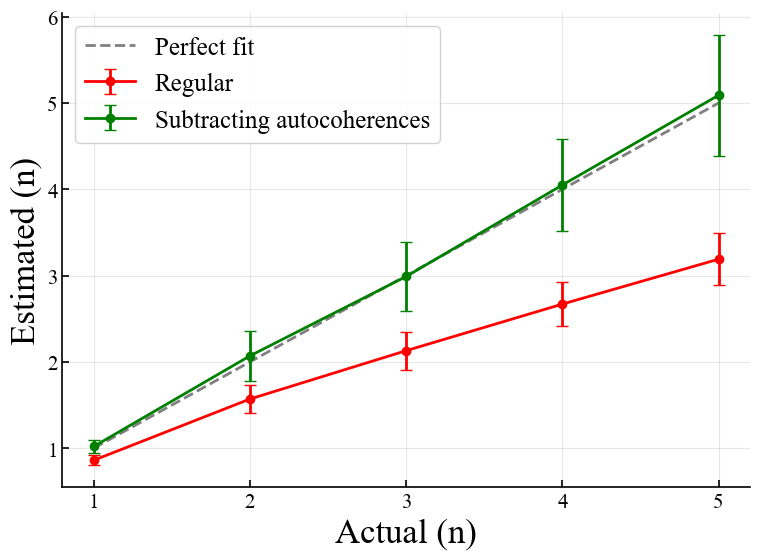

In [ ]:
# Actual: 1 | Estimated: 1.02 ± 0.08 | Error: 1.6%
# Actual: 2 | Estimated: 2.07 ± 0.29 | Error: 3.3%
# Actual: 3 | Estimated: 2.99 ± 0.40 | Error: 0.4%
# Actual: 4 | Estimated: 4.05 ± 0.53 | Error: 1.3%
# Actual: 5 | Estimated: 5.09 ± 0.70 | Error: 1.9%

import matplotlib.pyplot as plt
import numpy as np

# Actual n values
n_actual = np.array([1, 2, 3, 4, 5])

# Estimated values and errors for each noise source
data = {

    "Regular": {
        "est": np.array([0.86, 1.57, 2.13, 2.67, 3.19]),
        "err": np.array([0.06, 0.16, 0.22, 0.25, 0.30])
    },
    "Subtracting autocoherences": {
        "est": np.array([1.02, 2.07, 2.99, 4.05, 5.09]),
        "err": np.array([0.08, 0.29, 0.40, 0.53, 0.70])
    },
}

# Plot
plt.figure(figsize=(8,6))

# Perfect fit line
plt.plot(n_actual, n_actual, '--', color='gray', label='Perfect fit')

# Plot each noise source with error bars
colors = ['r', 'green', 'r', 'c', 'm']
for i, (label, vals) in enumerate(data.items()):
    plt.errorbar(n_actual, vals["est"], yerr=vals["err"], marker='o', capsize=4, label=label, color=colors[i])

plt.xlabel("Actual (n)", fontsize=25)
plt.ylabel("Estimated (n)", fontsize=25)
#plt.xlim(0,6)
plt.xticks(n_actual)
#plt.title("Effect of Individual Noise Sources on Estimation (k given)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

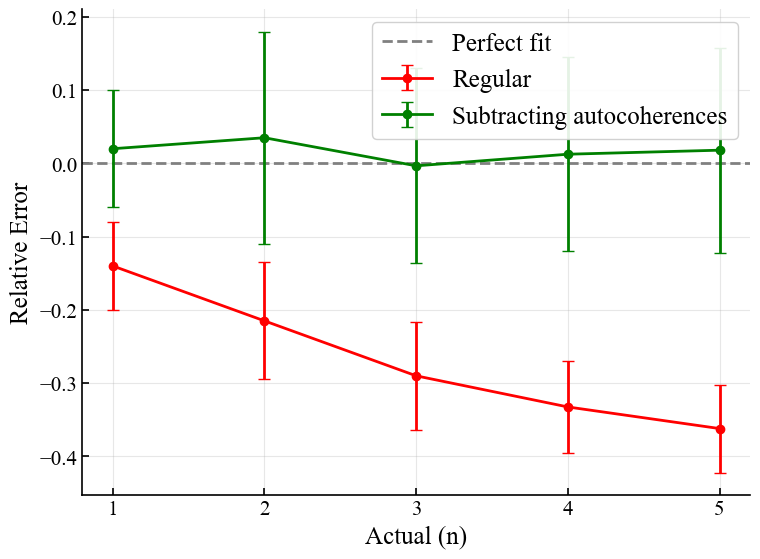

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Actual n values
n_actual = np.array([1, 2, 3, 4, 5])

# Estimated values and errors for each method
data = {
    "Regular": {
        "est": np.array([0.86, 1.57, 2.13, 2.67, 3.19]),
        "err": np.array([0.06, 0.16, 0.22, 0.25, 0.30])
    },
    "Subtracting autocoherences": {
        "est": np.array([1.02, 2.07, 2.99, 4.05, 5.09]),
        "err": np.array([0.08, 0.29, 0.40, 0.53, 0.70])
    },
}

# Function to compute relative error
def relative_error(estimated, actual):
    return (estimated - actual) / actual

# Plot relative errors
plt.figure(figsize=(8,6))

# Zero line for perfect fit
plt.axhline(0, color='gray', linestyle='--', label='Perfect fit')

# Plot each method with relative error
colors = ['r', 'green']
for i, (label, vals) in enumerate(data.items()):
    rel_err = relative_error(vals["est"], n_actual)
    plt.errorbar(n_actual, rel_err, yerr=vals["err"]/n_actual,  # scale error bars to relative
                 marker='o', capsize=4, label=label, color=colors[i])

plt.xlabel("Actual (n)", fontsize=18)
plt.ylabel("Relative Error", fontsize=18)
plt.xticks(n_actual)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


PSF Analysis Results (10 simulations)
Method       2σ PSF (nm)     Improvement 
----------------------------------------
Confocal     325 ± 4      1.00×
ISM          274 ± 1      1.18×
ΔG²          239 ± 6      1.36×
Q-ISM ΔG²    198 ± 1      1.64×

Individual simulation results (2σ PSF in nm):
--------------------------------------------------
Sim  Confocal ISM      ΔG²      Q-ISM   
1.0  323      276    231    199
2.0  320      272    235    196
3.0  326      274    242    199
4.0  329      275    242    199
5.0  325      275    242    197
6.0  331      273    252    200
7.0  322      276    235    197
8.0  321      274    234    200
9.0  323      275    235    198
10.0 327      273    241    198


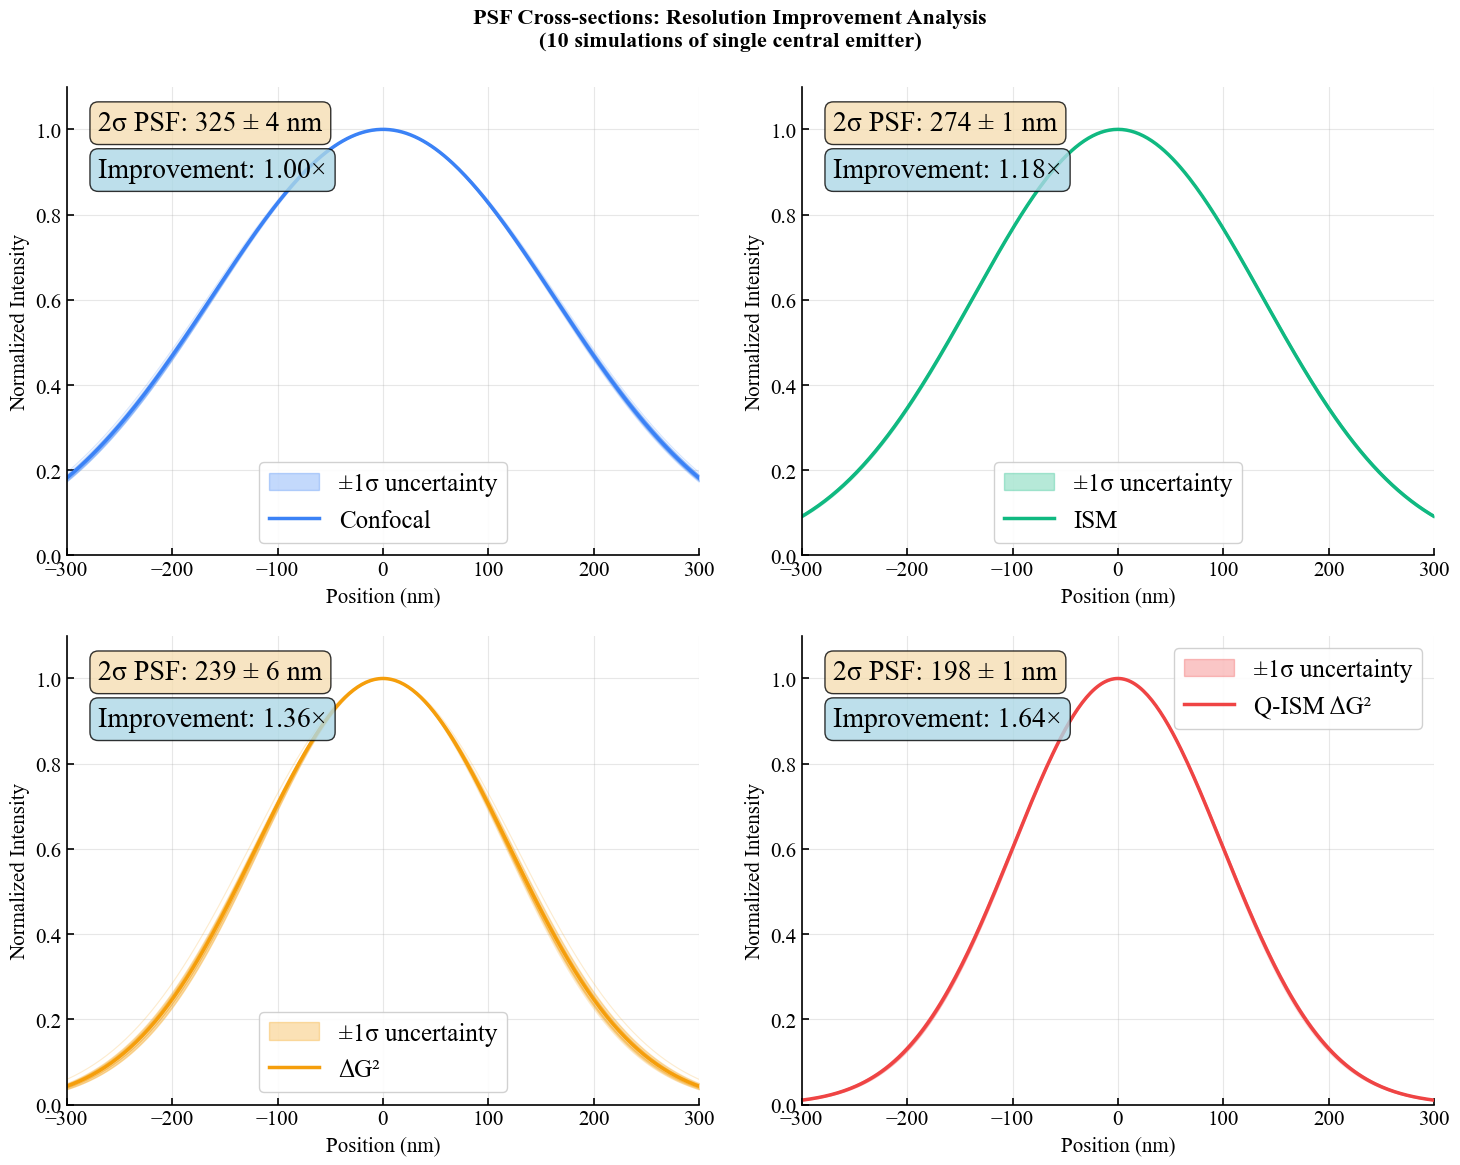

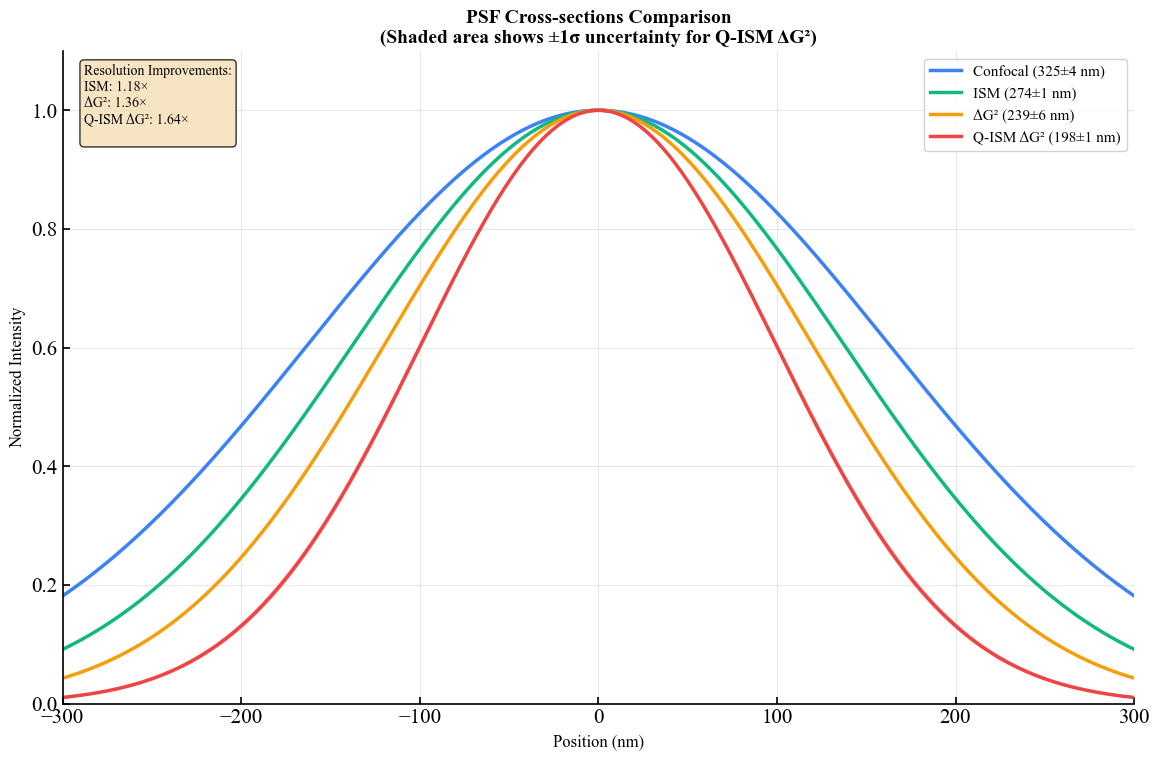

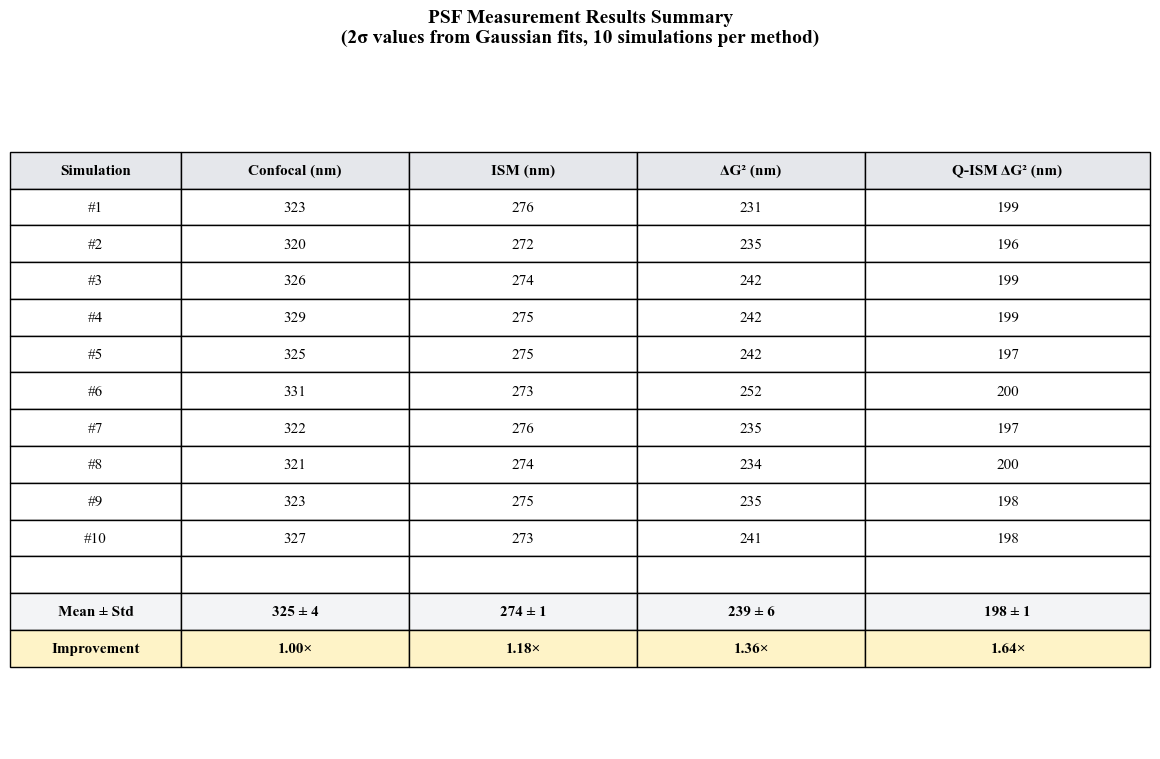


Figures generated:
1. Individual method plots with error bands and simulation overlays
2. Comparison plot showing all methods
3. Data summary table

Note: Error bands represent ±1 standard deviation from 10 independent simulations.
PSF sizes determined from 2σ values of fitted 1D Gaussian distributions.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# Raw data from your 10 simulations (sigma values in μm)
raw_data = {
    'sim': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'confocal': [0.1617, 0.1598, 0.1630, 0.1643, 0.1625, 0.1657, 0.1609, 0.1607, 0.1614, 0.1636],
    'ism': [0.1379, 0.1361, 0.1370, 0.1373, 0.1374, 0.1364, 0.1379, 0.1371, 0.1376, 0.1367],
    'g2_confocal': [0.1157, 0.1177, 0.1210, 0.1209, 0.1208, 0.1261, 0.1174, 0.1172, 0.1176, 0.1206],
    'g2_ism': [0.0997, 0.0978, 0.0996, 0.0993, 0.0987, 0.1001, 0.0986, 0.1001, 0.0988, 0.0992]
}

df = pd.DataFrame(raw_data)

# Calculate statistics for each method
def calc_stats(values):
    mean = np.mean(values)
    std = np.std(values, ddof=1)  # Sample standard deviation
    return mean, std

# Calculate 2σ PSF sizes in nm
methods = ['confocal', 'ism', 'g2_confocal', 'g2_ism']
method_names = ['Confocal', 'ISM', 'ΔG²', 'Q-ISM ΔG²']
colors = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444']

results = {}
for method in methods:
    mean_sigma, std_sigma = calc_stats(df[method])
    # Convert to 2σ PSF size in nm
    psf_mean = mean_sigma * 2 * 1000
    psf_std = std_sigma * 2 * 1000
    results[method] = {'mean': psf_mean, 'std': psf_std, 'sigma_mean': mean_sigma, 'sigma_std': std_sigma}

# Print results table
print("="*60)
print("PSF Analysis Results (10 simulations)")
print("="*60)
print(f"{'Method':<12} {'2σ PSF (nm)':<15} {'Improvement':<12}")
print("-"*40)

for i, method in enumerate(methods):
    improvement = results['confocal']['mean'] / results[method]['mean']
    print(f"{method_names[i]:<12} {results[method]['mean']:.0f} ± {results[method]['std']:.0f}      {improvement:.2f}×")

print("\nIndividual simulation results (2σ PSF in nm):")
print("-"*50)
print(f"{'Sim':<4} {'Confocal':<8} {'ISM':<8} {'ΔG²':<8} {'Q-ISM':<8}")
for _, row in df.iterrows():
    print(f"{row['sim']:<4} {row['confocal']*2000:.0f}      {row['ism']*2000:.0f}    {row['g2_confocal']*2000:.0f}    {row['g2_ism']*2000:.0f}")

# Generate Gaussian profiles for visualization
def generate_gaussian(sigma_um, amplitude=1, center=0, x_range=(-400, 400), step=2):
    """Generate Gaussian profile"""
    x_nm = np.arange(x_range[0], x_range[1] + step, step)
    x_um = x_nm / 1000  # convert to μm
    y = amplitude * np.exp(-0.5 * ((x_um - center) / sigma_um) ** 2)
    return x_nm, y

# Create figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('PSF Cross-sections: Resolution Improvement Analysis\n(10 simulations of single central emitter)', 
             fontsize=16, fontweight='bold')

# Individual method plots with error bands
x_pos = np.arange(-400, 401, 2)

for i, (method, ax, name, color) in enumerate(zip(methods, [ax1, ax2, ax3, ax4], method_names, colors)):
    # Mean profile
    x, y_mean = generate_gaussian(results[method]['sigma_mean'])
    
    # Upper and lower bounds for error band
    x, y_upper = generate_gaussian(results[method]['sigma_mean'] + results[method]['sigma_std'])
    x, y_lower = generate_gaussian(results[method]['sigma_mean'] - results[method]['sigma_std'])
    
    # Plot error band
    ax.fill_between(x, y_lower, y_upper, alpha=0.3, color=color, label=f'±1σ uncertainty')
    
    # Plot mean line
    ax.plot(x, y_mean, color=color, linewidth=2.5, label=f'{name}')
    
    # Add individual simulation profiles (lighter)
    for _, row in df.iterrows():
        x_sim, y_sim = generate_gaussian(row[method])
        ax.plot(x_sim, y_sim, color=color, alpha=0.2, linewidth=0.8)
    
    ax.set_xlim(-300, 300)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Position (nm)')
    ax.set_ylabel('Normalized Intensity')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add PSF size annotation
    psf_text = f'2σ PSF: {results[method]["mean"]:.0f} ± {results[method]["std"]:.0f} nm'
    improvement = results['confocal']['mean'] / results[method]['mean']
    imp_text = f'Improvement: {improvement:.2f}×'
    ax.text(0.05, 0.95, psf_text, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.text(0.05, 0.85, imp_text, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

# Comparison plot
plt.figure(figsize=(12, 8))

for i, (method, name, color) in enumerate(zip(methods, method_names, colors)):
    x, y = generate_gaussian(results[method]['sigma_mean'])
    label = f'{name} ({results[method]["mean"]:.0f}±{results[method]["std"]:.0f} nm)'
    plt.plot(x, y, color=color, linewidth=2.5, label=label)
    
    # Add error band for the most improved method (Q-ISM)
    if method == 'g2_ism':
        x, y_upper = generate_gaussian(results[method]['sigma_mean'] + results[method]['sigma_std'])
        x, y_lower = generate_gaussian(results[method]['sigma_mean'] - results[method]['sigma_std'])
        plt.fill_between(x, y_lower, y_upper, alpha=0.2, color=color)

plt.xlim(-300, 300)
plt.ylim(0, 1.1)
plt.xlabel('Position (nm)', fontsize=12)
plt.ylabel('Normalized Intensity', fontsize=12)
plt.title('PSF Cross-sections Comparison\n(Shaded area shows ±1σ uncertainty for Q-ISM ΔG²)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Add text box with key results
textstr = 'Resolution Improvements:\n'
for i, method in enumerate(methods[1:], 1):
    improvement = results['confocal']['mean'] / results[method]['mean']
    textstr += f'{method_names[i]}: {improvement:.2f}× \n'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Data summary table as a figure
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('tight')
ax.axis('off')

# Create table data
table_data = []
table_data.append(['Simulation', 'Confocal (nm)', 'ISM (nm)', 'ΔG² (nm)', 'Q-ISM ΔG² (nm)'])
for _, row in df.iterrows():
    table_data.append([
        f"#{int(row['sim'])}",
        f"{row['confocal']*2000:.0f}",
        f"{row['ism']*2000:.0f}", 
        f"{row['g2_confocal']*2000:.0f}",
        f"{row['g2_ism']*2000:.0f}"
    ])

# Add summary statistics
table_data.append(['', '', '', '', ''])
table_data.append(['Mean ± Std', 
                  f"{results['confocal']['mean']:.0f} ± {results['confocal']['std']:.0f}",
                  f"{results['ism']['mean']:.0f} ± {results['ism']['std']:.0f}",
                  f"{results['g2_confocal']['mean']:.0f} ± {results['g2_confocal']['std']:.0f}",
                  f"{results['g2_ism']['mean']:.0f} ± {results['g2_ism']['std']:.0f}"])

table_data.append(['Improvement', '1.00×',
                  f"{results['confocal']['mean']/results['ism']['mean']:.2f}×",
                  f"{results['confocal']['mean']/results['g2_confocal']['mean']:.2f}×", 
                  f"{results['confocal']['mean']/results['g2_ism']['mean']:.2f}×"])

# Create table
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.15, 0.2, 0.2, 0.2, 0.25])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style the table
for i in range(len(table_data)):
    for j in range(len(table_data[i])):
        cell = table[(i, j)]
        if i == 0:  # Header
            cell.set_facecolor('#E5E7EB')
            cell.set_text_props(weight='bold')
        elif i == len(table_data) - 2:  # Mean row
            cell.set_facecolor('#F3F4F6')
            cell.set_text_props(weight='bold')
        elif i == len(table_data) - 1:  # Improvement row
            cell.set_facecolor('#FEF3C7')
            cell.set_text_props(weight='bold')
        elif i == len(table_data) - 3:  # Empty row
            cell.set_facecolor('white')
        else:
            cell.set_facecolor('white')

plt.title('PSF Measurement Results Summary\n(2σ values from Gaussian fits, 10 simulations per method)', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nFigures generated:")
print("1. Individual method plots with error bands and simulation overlays")
print("2. Comparison plot showing all methods")
print("3. Data summary table")
print(f"\nNote: Error bands represent ±1 standard deviation from {len(df)} independent simulations.")
print("PSF sizes determined from 2σ values of fitted 1D Gaussian distributions.")


## Deprecated code

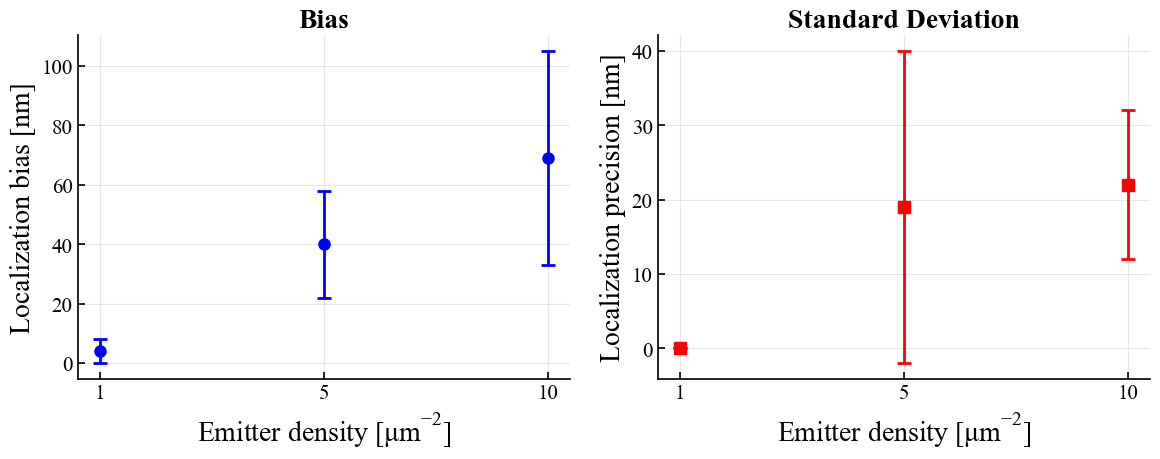

In [ ]:
# DEPRECATED CODE - DO NOT USE

# Your data - modify these values
x_values = ['1', '5', '10']  # emitter densities

# Data for first subplot
y_values1 = [0.004, 0.040, 0.069]           
y_errors1 =  [0.004, 0.018, 0.036] 
y_values1 = [value * 1000 for value in y_values1]  # Convert to nm
y_errors1 = [error * 1000 for error in y_errors1]  # Convert to nm            

# Data for second subplot
y_values2 = [0, 0.019, 0.022]                      # Y-axis values (means)
y_errors2 = [0, 0.021, 0.010]                   # Error bar values
y_values2 = [value * 1000 for value in y_values2]  # Convert to nm
y_errors2 = [error * 1000 for error in y_errors2]  # Convert to nm    

# Corresponding data: data_directory = "project/data/evaluation_20250708_150117/"
    #data_directory = "project/data/evaluation_20250708_150248/"
    #data_directory = "project/data/evaluation_20250708_150829/"
# Data created with evaluate_localization_algorithm.py

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot
ax1.errorbar(x_values, y_values1, yerr=y_errors1, 
             fmt='o',           # Circle markers
             capsize=5,         # Cap size for error bars
             capthick=2,        # Cap thickness
             markersize=8,      # Marker size
             linewidth=2,       # Line width
             color='blue')

ax1.set_xlabel(r'Emitter density [$\mu m^{-2}$]', fontsize=20)
ax1.set_ylabel('Localization bias [nm]', fontsize=20)
ax1.set_title('Bias', fontsize=20)
ax1.grid(True, alpha=0.3)

# Second subplot
ax2.errorbar(x_values, y_values2, yerr=y_errors2, 
             fmt='s',           # Square markers
             capsize=5,         # Cap size for error bars
             capthick=2,        # Cap thickness
             markersize=8,      # Marker size
             linewidth=2,       # Line width
             color='red')

ax2.set_xlabel(r'Emitter density [$\mu m^{-2}$]', fontsize=20)
ax2.set_ylabel('Localization precision [nm]', fontsize=20)
ax2.set_title('Standard Deviation', fontsize=20)
ax2.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()